In [ ]:
# ===================================================================
# ISNet PNEUMONIA — FULL CONSOLIDATED RECOVERY CELL
# ===================================================================

import os
import json
import sys
import cv2
import numpy as np
import torch
from google.colab import drive
from torch.utils.data import Dataset, DataLoader
import albumentations as A

# ---- 1. Drive mount ----
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted.")

# ---- 2. Main repo clone/pull ----
repo_dir = '/content/drive/MyDrive/MediScan_AI/repo'
if not os.path.exists(repo_dir):
    !git clone https://github.com/zimcodes1/MEDISCAN.git {repo_dir}
%cd {repo_dir}
!git checkout training/model-development
!git pull
if repo_dir not in sys.path:
    sys.path.append(repo_dir)

# ---- 3. CheXpert split ----
split_path = '/content/drive/MyDrive/MediScan_AI/training/datasets/pneumonia_chexpert/split.json'
with open(split_path) as f:
    split_data = json.load(f)
train_pairs = split_data['train']
val_pairs = split_data['val']
test_pairs = split_data['test']
print(f"CheXpert split loaded — train: {len(train_pairs)}, val: {len(val_pairs)}, test: {len(test_pairs)}")

# ---- 4. Raw CheXpert images — check, and re-download if missing ----
raw_present = os.path.exists(train_pairs[0][0])
print("Raw CheXpert images on VM disk:", raw_present)
if not raw_present:
    print("Re-downloading CheXpert dataset (this will take a few minutes)...")
    !kaggle datasets download -d ashery/chexpert -p /content/
    !unzip -q /content/chexpert.zip -d /content/chexpert_data/
    print("Re-download complete. Re-checking...")
    print("Raw CheXpert images on VM disk now:", os.path.exists(train_pairs[0][0]))

# ---- 5. Cached lung masks ----
mask_cache_dir = '/content/drive/MyDrive/MediScan_AI/training/datasets/pneumonia_chexpert/lung_masks'
mask_mapping_path = os.path.join(mask_cache_dir, 'mask_mapping.json')
with open(mask_mapping_path) as f:
    mask_mapping = json.load(f)
print(f"Mask mapping loaded — {len(mask_mapping)} masks cached.")

# ---- 6. pip<24.1 + pytorch-lightning==1.6.3 ----
!pip install -q "pip<24.1"
!pip install -q "pytorch-lightning==1.6.3"
import pytorch_lightning as pl
print("Lightning version:", pl.__version__)

# ---- 7. ISNet repo imports ----
isnet_code_dir = '/content/drive/MyDrive/MediScan_AI/ISNet_repo/code'
if isnet_code_dir not in sys.path:
    sys.path.append(isnet_code_dir)
import LRPDenseNetZe
import ISNetFlexLightning
print("ISNet imports ready.")

# ---- 8. Device ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# ---- 9. preprocess_isnet function ----
def preprocess_isnet(image_path, mask, train=False):
    img = cv2.imread(image_path, 0)
    if img is None:
        raise FileNotFoundError(f"Could not read image at {image_path} — raw data may be missing.")

    if not train:
        h, w = img.shape
        size = max(h, w)
        pad_img = np.zeros((size, size), dtype=img.dtype)
        y_off = (size - h) // 2
        x_off = (size - w) // 2
        pad_img[y_off:y_off+h, x_off:x_off+w] = img
        img = pad_img

    img = cv2.equalizeHist(img)
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_LINEAR)

    if train:
        transform = A.Compose([
            A.Affine(translate_px=(-28, 28), rotate=(-40, 40), p=1.0),
            A.HorizontalFlip(p=0.5),
        ])
        augmented = transform(image=img, mask=mask)
        img = augmented['image']
        mask = augmented['mask']

    img_3ch = np.stack([img] * 3, axis=0).astype(np.float32) / 255.0
    return img_3ch, mask

# ---- 10. Dataset class ----
class ISNetPneumoniaDataset(Dataset):
    def __init__(self, pairs, mask_mapping, train=False):
        self.pairs = pairs
        self.mask_mapping = mask_mapping
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path, label = self.pairs[idx]
        mask = np.load(self.mask_mapping[path])
        img_arr, mask_arr = preprocess_isnet(path, mask, train=self.train)
        image_tensor = torch.from_numpy(img_arr).float()
        mask_tensor = torch.from_numpy(mask_arr).float()
        label_tensor = torch.tensor([label], dtype=torch.float32)
        return image_tensor, mask_tensor, label_tensor

print("\n✅ FULL RECOVERY COMPLETE — ready to continue.")

Mounted at /content/drive
/content/drive/MyDrive/MediScan_AI/repo
Already on 'training/model-development'
Your branch is up to date with 'origin/training/model-development'.
Already up to date.
CheXpert split loaded — train: 14740, val: 1840, test: 1816
Raw CheXpert images on VM disk: False
Re-downloading CheXpert dataset (this will take a few minutes)...
Dataset URL: https://www.kaggle.com/datasets/ashery/chexpert
License(s): CC0-1.0
100% 10.7G/10.7G [01:17<00:00, 148MB/s] 

Re-download complete. Re-checking...
Raw CheXpert images on VM disk now: True


remaining imports to ease recovery

In [2]:
from torch.utils.data import Dataset, DataLoader

In [3]:
train_dataset = ISNetPneumoniaDataset(train_pairs, mask_mapping, train=True)
val_dataset = ISNetPneumoniaDataset(val_pairs, mask_mapping, train=False)
test_dataset = ISNetPneumoniaDataset(test_pairs, mask_mapping, train=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# sanity check one batch
batch_images, batch_masks, batch_labels = next(iter(train_loader))
print(batch_images.shape, batch_masks.shape, batch_labels.shape)

torch.Size([16, 3, 224, 224]) torch.Size([16, 224, 224]) torch.Size([16, 1])


In [4]:
class ISNetPneumoniaDataset(Dataset):
    def __init__(self, pairs, mask_mapping, train=False):
        self.pairs = pairs
        self.mask_mapping = mask_mapping
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path, label = self.pairs[idx]

        mask = np.load(self.mask_mapping[path])

        img_arr, mask_arr = preprocess_isnet(
            path,
            mask,
            train=self.train
        )

        image_tensor = torch.from_numpy(img_arr).float()
        mask_tensor = torch.from_numpy(mask_arr).float()

        # ISNet is configured with classes=2,
        # so labels must be integer class indices: 0 or 1.
        label_tensor = torch.tensor(
            [label],
            dtype=torch.long
        )

        return image_tensor, mask_tensor, label_tensor

In [5]:
import json

mask_cache_dir = '/content/drive/MyDrive/MediScan_AI/training/datasets/pneumonia_chexpert/lung_masks'
with open(os.path.join(mask_cache_dir, 'mask_mapping.json')) as f:
    mask_mapping = json.load(f)

print(f"Mask mapping loaded — {len(mask_mapping)} entries.")

Mask mapping loaded — 18396 entries.


In [6]:
train_dataset = ISNetPneumoniaDataset(train_pairs, mask_mapping, train=True)
val_dataset = ISNetPneumoniaDataset(val_pairs, mask_mapping, train=False)
test_dataset = ISNetPneumoniaDataset(test_pairs, mask_mapping, train=False)

In [7]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
True


checking out the FasterISNet repo if the requirements.txt is compatible

In [3]:
faster_isnet_dir = '/content/drive/MyDrive/MediScan_AI/FasterISNet_repo'
if not os.path.exists(faster_isnet_dir):
    !git clone https://github.com/PedroRASB/FasterISNet.git {faster_isnet_dir}

with open(f'{faster_isnet_dir}/requirements.txt') as f:
    print(f.read())

Cloning into '/content/drive/MyDrive/MediScan_AI/FasterISNet_repo'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 128 (delta 64), reused 15 (delta 11), pack-reused 31 (from 1)
Receiving objects: 100% (128/128), 108.21 KiB | 2.30 MiB/s, done.
Resolving deltas: 100% (70/70), done.
#conda create --name isnet python=3.8
#conda activate isnet
#conda install pip=23.3.2
#conda install ipykernel
#pip install torch==1.11.0+cu113 torchvision==0.12.0+cu113 --extra-index-url https://download.pytorch.org/whl/cu113
#pip install -r requirements.txt
torch==1.11.0
torchvision==0.12.0
pytorch-lightning==1.6.3
h5py
scikit-learn
matplotlib
pandas
opencv-python
tqdm
tensorboard
scikit-image



In [4]:
# confirming it it's usable
import pytorch_lightning as pl
print(pl.__version__)

trainer = pl.Trainer(max_epochs=1)
print("Trainer instantiated successfully")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


1.6.3
Trainer instantiated successfully


/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/trainer.py:1812: PossibleUserWarning: GPU available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='gpu', devices=1)`.
  rank_zero_warn(


In [2]:
import sys
isnet_code_dir = '/content/drive/MyDrive/MediScan_AI/ISNet_repo/code'
if isnet_code_dir not in sys.path:
    sys.path.append(isnet_code_dir)

import LRPDenseNetZe
import ISNetFlexLightning

DenseNet = LRPDenseNetZe.densenet121(pretrained=False)
print(type(DenseNet))
print("ISNet DenseNet121 base architecture loaded successfully.")

<class 'LRPDenseNetZe.DenseNet'>
ISNet DenseNet121 base architecture loaded successfully.


generating whole-image lung segmentation masks for the CheXpert Pneumonia dataset, which ISNet needs as training targets.

In [6]:
!pip install "transformers<5.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 123.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 117.5 MB/s eta 0:00:00
DEPRECATION: pytorch-lightning 1.6.3 has a non-standard dependency specifier torch>=1.8.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.28.0
    Uninstalling huggingface_hub-1.28.0:
      Successfully uninstalled huggingface_hub-1.28.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.23.1
    Uninstal

In [ ]:
import os
os.kill(os.getpid(), 9)

: 

: 

: 

In [2]:
import sys
isnet_code_dir = '/content/drive/MyDrive/MediScan_AI/ISNet_repo/code'
if isnet_code_dir not in sys.path:
    sys.path.append(isnet_code_dir)

import torch
from transformers import AutoModel

seg_model = AutoModel.from_pretrained("ianpan/chest-x-ray-basic", trust_remote_code=True)
seg_model = seg_model.eval().to(device)
print("Segmentation model loaded.")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/708 [00:00<?, ?B/s]

configuration.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ianpan/chest-x-ray-basic:
- configuration.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling.py: 0.00B [00:00, ?B/s]

unet.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ianpan/chest-x-ray-basic:
- unet.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/ianpan/chest-x-ray-basic:
- modeling.py
- unet.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/89.1M [00:00<?, ?B/s]

Segmentation model loaded.


In [3]:
import cv2
import numpy as np
from PIL import Image

def generate_lung_mask_224(image_path):
    """
    Returns a binary (0/1) numpy mask at 224x224, where 1 = lung tissue
    (combining left + right lung classes from the segmentation model),
    0 = background. This is what ISNet uses as its training-time target
    for background-relevance minimization — NOT a crop, the full image
    stays intact.
    """
    img = cv2.imread(image_path, 0)  # grayscale
    x = seg_model.preprocess(img)
    x_tensor = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.inference_mode():
        out = seg_model(x_tensor)
    raw_mask = out["mask"].argmax(1).squeeze(0).cpu().numpy()  # 320x320, values 0-3

    lung_mask = ((raw_mask == 1) | (raw_mask == 2)).astype(np.uint8)  # binary lung mask
    lung_mask_224 = cv2.resize(lung_mask, (224, 224), interpolation=cv2.INTER_NEAREST)

    return lung_mask_224


# quick test on one image
test_path = train_pairs[0][0] if isinstance(train_pairs[0], list) else train_pairs[0][0]
test_mask = generate_lung_mask_224(test_path)
print(test_mask.shape, test_mask.dtype, "unique values:", np.unique(test_mask))

AttributeError: 'NoneType' object has no attribute 'shape'

In [4]:
print(train_pairs[0])
print(type(train_pairs[0]))

['/content/chexpert_data/train/patient00085/study1/view1_frontal.jpg', 1]
<class 'list'>


In [5]:
import os
test_path = train_pairs[0][0]
print(test_path)
print("File exists on disk:", os.path.exists(test_path))

/content/chexpert_data/train/patient00085/study1/view1_frontal.jpg
File exists on disk: False


In [7]:
import os
print("File exists now:", os.path.exists(test_path))

test_mask = generate_lung_mask_224(test_path)
print(test_mask.shape, test_mask.dtype, "unique values:", np.unique(test_mask))

File exists now: True
(224, 224) uint8 unique values: [0 1]


In [8]:
import cv2
import numpy as np
from PIL import Image

def generate_lung_mask_224(image_path):
    """
    Returns a binary (0/1) numpy mask at 224x224, where 1 = lung tissue
    (combining left + right lung classes from the segmentation model),
    0 = background. This is what ISNet uses as its training-time target
    for background-relevance minimization — NOT a crop, the full image
    stays intact.
    """
    img = cv2.imread(image_path, 0)  # grayscale
    x = seg_model.preprocess(img)
    x_tensor = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.inference_mode():
        out = seg_model(x_tensor)
    raw_mask = out["mask"].argmax(1).squeeze(0).cpu().numpy()  # 320x320, values 0-3

    lung_mask = ((raw_mask == 1) | (raw_mask == 2)).astype(np.uint8)  # binary lung mask
    lung_mask_224 = cv2.resize(lung_mask, (224, 224), interpolation=cv2.INTER_NEAREST)

    return lung_mask_224


# quick test on one image
test_path = train_pairs[0][0] if isinstance(train_pairs[0], list) else train_pairs[0][0]
test_mask = generate_lung_mask_224(test_path)
print(test_mask.shape, test_mask.dtype, "unique values:", np.unique(test_mask))

(224, 224) uint8 unique values: [0 1]


visualizing lung mask generation

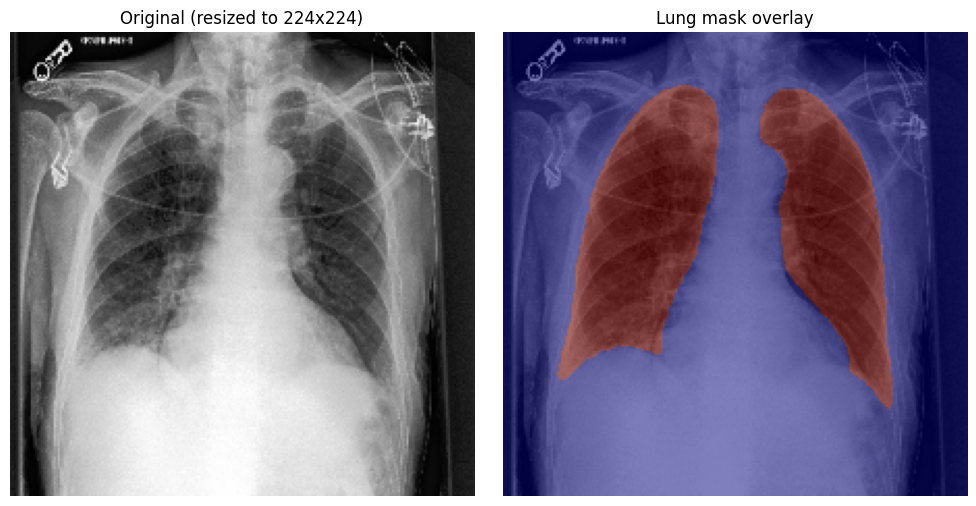

In [9]:
import matplotlib.pyplot as plt

img_display = cv2.imread(test_path, 0)
img_display_resized = cv2.resize(img_display, (224, 224))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_display_resized, cmap='gray')
axes[0].set_title("Original (resized to 224x224)")
axes[0].axis('off')

axes[1].imshow(img_display_resized, cmap='gray')
axes[1].imshow(test_mask, alpha=0.5, cmap='jet')
axes[1].set_title("Lung mask overlay")
axes[1].axis('off')

plt.tight_layout()
plt.show()

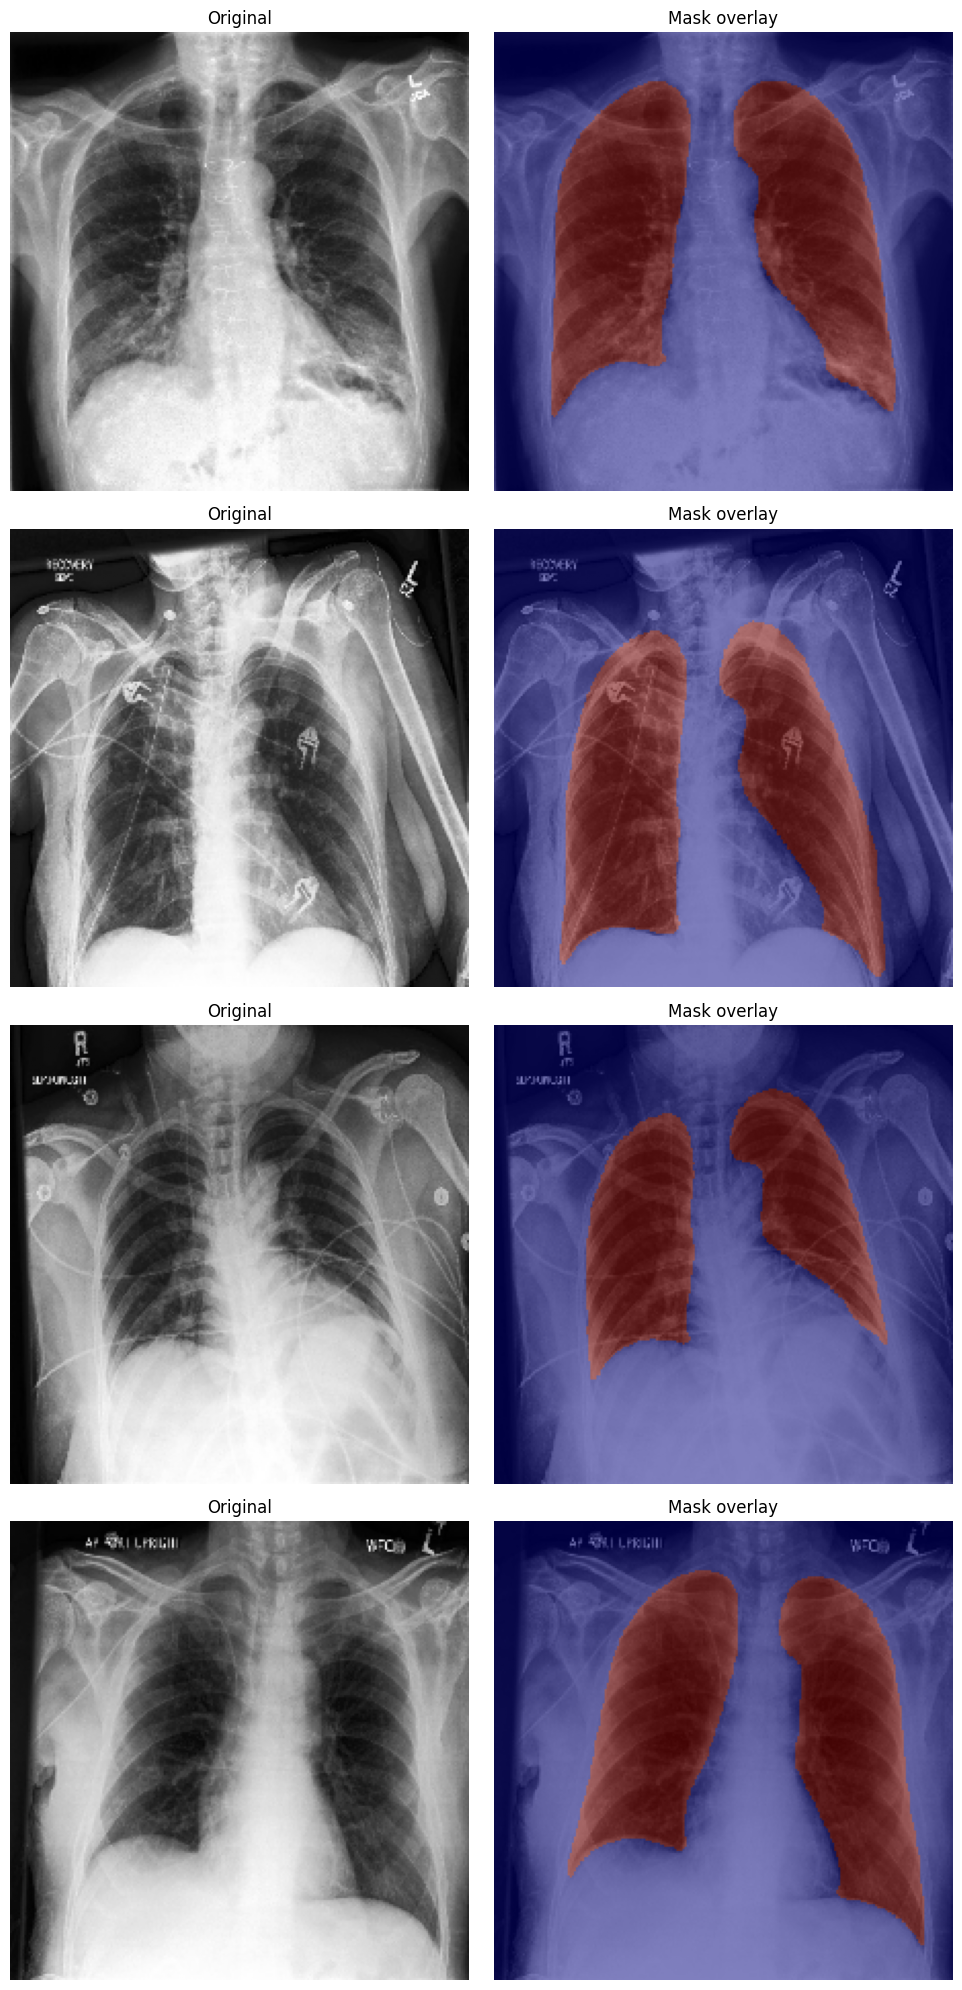

In [10]:
import random
random.seed(1)
check_indices = random.sample(range(len(train_pairs)), 4)

fig, axes = plt.subplots(4, 2, figsize=(10, 20))
for i, idx in enumerate(check_indices):
    path = train_pairs[idx][0]
    if not os.path.exists(path):
        print(f"Skipping missing file: {path}")
        continue

    mask = generate_lung_mask_224(path)
    img_disp = cv2.imread(path, 0)
    img_disp_resized = cv2.resize(img_disp, (224, 224))

    axes[i, 0].imshow(img_disp_resized, cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img_disp_resized, cmap='gray')
    axes[i, 1].imshow(mask, alpha=0.5, cmap='jet')
    axes[i, 1].set_title("Mask overlay")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

generating masks for the entire dataset

In [11]:
import numpy as np

mask_cache_dir = '/content/drive/MyDrive/MediScan_AI/training/datasets/pneumonia_chexpert/lung_masks'
os.makedirs(mask_cache_dir, exist_ok=True)

def generate_and_cache_masks(pairs, cache_dir, save_every=250):
    mapping_path = os.path.join(cache_dir, 'mask_mapping.json')

    if os.path.exists(mapping_path):
        with open(mapping_path) as f:
            mask_mapping = json.load(f)
        print(f"Resuming — {len(mask_mapping)} masks already generated.")
    else:
        mask_mapping = {}

    skipped = []
    for i, (path, label) in enumerate(pairs):
        if path in mask_mapping:
            continue

        if not os.path.exists(path):
            skipped.append(path)
            continue

        try:
            mask = generate_lung_mask_224(path)
        except Exception as e:
            print(f"Failed on {path}: {e}")
            skipped.append(path)
            continue

        mask_filename = f"{i:06d}.npy"
        mask_path = os.path.join(cache_dir, mask_filename)
        np.save(mask_path, mask)
        mask_mapping[path] = mask_path

        if (i + 1) % save_every == 0:
            print(f"Processed {i+1}/{len(pairs)} ({len(skipped)} skipped so far)")
            with open(mapping_path, 'w') as f:
                json.dump(mask_mapping, f, indent=2)

    with open(mapping_path, 'w') as f:
        json.dump(mask_mapping, f, indent=2)

    print(f"Done. Total masks: {len(mask_mapping)}, skipped: {len(skipped)}")
    return mask_mapping, skipped

In [12]:
print("Generating masks for train split...")
train_mask_mapping, train_skipped = generate_and_cache_masks(train_pairs, mask_cache_dir)

Generating masks for train split...
Processed 250/14740 (0 skipped so far)
Processed 500/14740 (0 skipped so far)
Processed 750/14740 (0 skipped so far)
Processed 1000/14740 (0 skipped so far)
Processed 1250/14740 (0 skipped so far)
Processed 1500/14740 (0 skipped so far)
Processed 1750/14740 (0 skipped so far)
Processed 2000/14740 (0 skipped so far)
Processed 2250/14740 (0 skipped so far)
Processed 2500/14740 (0 skipped so far)
Processed 2750/14740 (0 skipped so far)
Processed 3000/14740 (0 skipped so far)
Processed 3250/14740 (0 skipped so far)
Processed 3500/14740 (0 skipped so far)
Processed 3750/14740 (0 skipped so far)
Processed 4000/14740 (0 skipped so far)
Processed 4250/14740 (0 skipped so far)
Processed 4500/14740 (0 skipped so far)
Processed 4750/14740 (0 skipped so far)
Processed 5000/14740 (0 skipped so far)
Processed 5250/14740 (0 skipped so far)
Processed 5500/14740 (0 skipped so far)
Processed 5750/14740 (0 skipped so far)
Processed 6000/14740 (0 skipped so far)
Process

In [13]:
# val sna test splits
print("Generating masks for val split...")
val_mask_mapping, val_skipped = generate_and_cache_masks(val_pairs, mask_cache_dir)

print("Generating masks for test split...")
test_mask_mapping, test_skipped = generate_and_cache_masks(test_pairs, mask_cache_dir)

Generating masks for val split...
Resuming — 14740 masks already generated.
Processed 250/1840 (0 skipped so far)
Processed 500/1840 (0 skipped so far)
Processed 750/1840 (0 skipped so far)
Processed 1000/1840 (0 skipped so far)
Processed 1250/1840 (0 skipped so far)
Processed 1500/1840 (0 skipped so far)
Processed 1750/1840 (0 skipped so far)
Done. Total masks: 16580, skipped: 0
Generating masks for test split...
Resuming — 16580 masks already generated.
Processed 250/1816 (0 skipped so far)
Processed 500/1816 (0 skipped so far)
Processed 750/1816 (0 skipped so far)
Processed 1000/1816 (0 skipped so far)
Processed 1250/1816 (0 skipped so far)
Processed 1500/1816 (0 skipped so far)
Processed 1750/1816 (0 skipped so far)
Done. Total masks: 18396, skipped: 0


In [6]:
import albumentations as A
import cv2
import numpy as np

def preprocess_isnet(image_path, mask, train=False):
    """
    ISNet paper's chest X-ray preprocessing recipe:
    - grayscale, histogram equalization
    - resize to 224x224, replicate to 3 channels
    - training augmentation: translation, rotation, flip
    - test images padded to square before resize (NOT applied at train time)
    """
    img = cv2.imread(image_path, 0)

    if not train:
        # pad to square with black bars before resizing, test-time only
        h, w = img.shape
        size = max(h, w)
        pad_img = np.zeros((size, size), dtype=img.dtype)
        y_off = (size - h) // 2
        x_off = (size - w) // 2
        pad_img[y_off:y_off+h, x_off:x_off+w] = img
        img = pad_img

    img = cv2.equalizeHist(img)
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_LINEAR)

    if train:
        transform = A.Compose([
            A.Affine(translate_px=(-28, 28), rotate=(-40, 40), p=1.0),
            A.HorizontalFlip(p=0.5),
        ])
        augmented = transform(image=img, mask=mask)
        img = augmented['image']
        mask = augmented['mask']  # mask must undergo the SAME spatial transform as the image

    img_3ch = np.stack([img] * 3, axis=0).astype(np.float32) / 255.0  # CHW, [0,1]

    return img_3ch, mask

In [20]:
test_path = train_pairs[0][0]
test_mask = np.load(train_mask_mapping[test_path])

img_out, mask_out = preprocess_isnet(test_path, test_mask, train=True)
print(img_out.shape, img_out.dtype, img_out.min(), img_out.max())
print(mask_out.shape, mask_out.dtype, np.unique(mask_out))

(3, 224, 224) float32 0.0 1.0
(224, 224) uint8 [0 1]


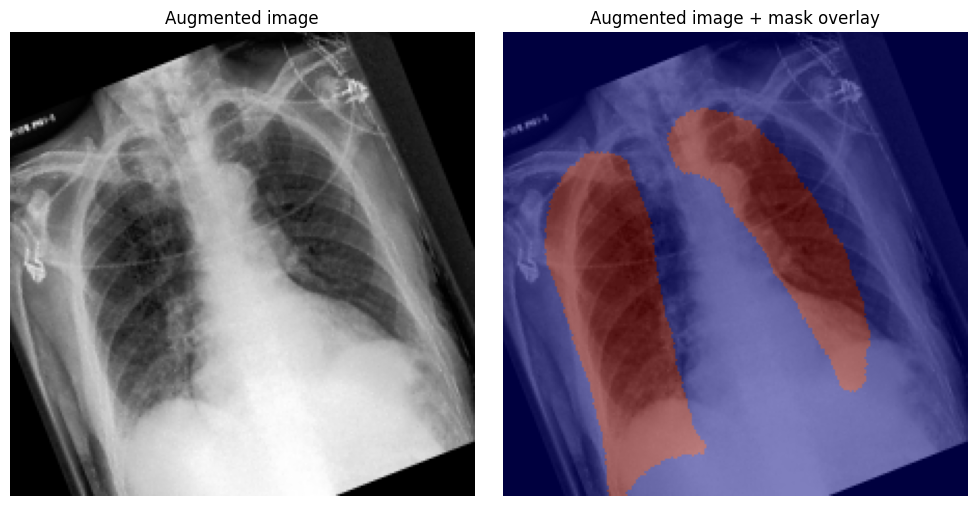

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_out[0], cmap='gray')  # take one channel, since all 3 are identical
axes[0].set_title("Augmented image")
axes[0].axis('off')

axes[1].imshow(img_out[0], cmap='gray')
axes[1].imshow(mask_out, alpha=0.5, cmap='jet')
axes[1].set_title("Augmented image + mask overlay")
axes[1].axis('off')

plt.tight_layout()
plt.show()

TypeError: Invalid shape (3, 224, 224) for image data

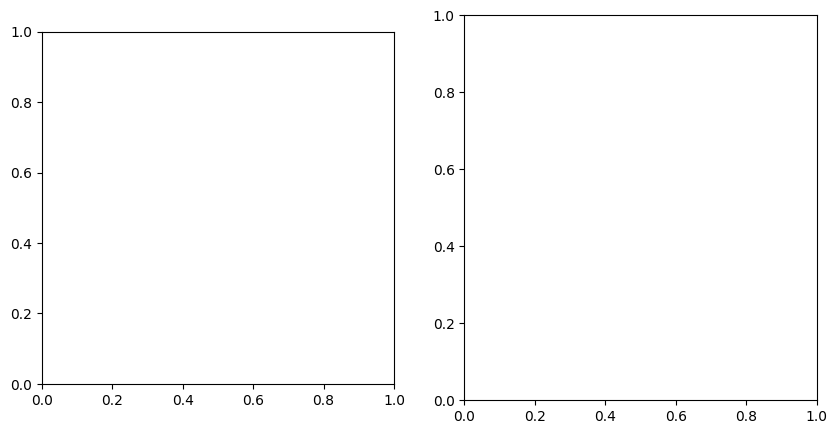

In [22]:
# No augmentation at all — baseline mask quality
img_base, mask_base = preprocess_isnet(test_path, test_mask, train=False)

# Rotation only, no translation/flip — isolate rotation's specific effect
import albumentations as A

rotation_only = A.Compose([A.Affine(rotate=(-40, 40), p=1.0)])
augmented = rotation_only(image=cv2.equalizeHist(cv2.resize(cv2.imread(test_path, 0), (224, 224))), mask=test_mask)
img_rot, mask_rot = augmented['image'], augmented['mask']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_base, cmap='gray')
axes[0].imshow(mask_base, alpha=0.5, cmap='jet')
axes[0].set_title("No rotation")
axes[0].axis('off')

axes[1].imshow(img_rot, cmap='gray')
axes[1].imshow(mask_rot, alpha=0.5, cmap='jet')
axes[1].set_title("Rotation only")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Mask unique values, no rotation:", np.unique(mask_base))
print("Mask unique values, with rotation:", np.unique(mask_rot))

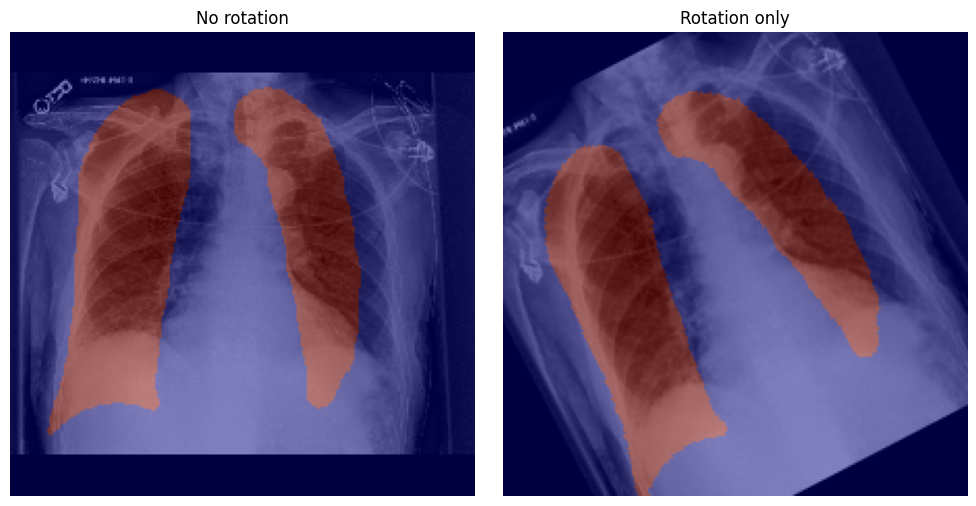

Mask unique values, no rotation: [0 1]
Mask unique values, with rotation: [0 1]


In [23]:
img_base, mask_base = preprocess_isnet(test_path, test_mask, train=False)

rotation_only = A.Compose([A.Affine(rotate=(-40, 40), p=1.0)])
augmented = rotation_only(image=cv2.equalizeHist(cv2.resize(cv2.imread(test_path, 0), (224, 224))), mask=test_mask)
img_rot, mask_rot = augmented['image'], augmented['mask']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_base[0], cmap='gray')  # take channel 0, since it's CHW
axes[0].imshow(mask_base, alpha=0.5, cmap='jet')
axes[0].set_title("No rotation")
axes[0].axis('off')

axes[1].imshow(img_rot, cmap='gray')
axes[1].imshow(mask_rot, alpha=0.5, cmap='jet')
axes[1].set_title("Rotation only")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Mask unique values, no rotation:", np.unique(mask_base))
print("Mask unique values, with rotation:", np.unique(mask_rot))

In [24]:
!cat /content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetLightningZe.py | head -100

import torch
import torch.nn.functional as F
import torch.nn as nn
import ISNetLayersZe as ISNetLayers
import ISNetFunctionsZe as ISNetFunctions
import LRPDenseNetZe as LRPDenseNet
import globalsZe as globals
import pytorch_lightning as pl
import warnings
from collections import OrderedDict
import numpy as np
import torchvision
import sys
sys.path.append('../')

import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')


class ISNetLgt(pl.LightningModule):
    def __init__(self,multiLabel=False,
                 classes=1000,architecture='densenet121',
                 e=1e-2,heat=True,
                 Zb=True,pretrained=False,
                 LR=1e-3,P=0.7,E=10,
                 A=1,B=3,d=0.996,
                 cut=1,cut2=25,
                 norm=True,optim='SGD',
                 Cweight=None,rule='e',multiple=True,
                 ignore=None,
                 dropLr=None, selective=False,
                 highest=False, baseModel=None,
            

In [25]:
!sed -n '100,220p' /content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetLightningZe.py

        
        if (ignore is not None and selective):
            raise ValueError('class ignore not implemented for selective output')
        
        if (baseModel==None):
            if pretrained:
                classesBackup=classes
                classes=1000
            if (architecture=='densenet121'):
                self.classifierDNN=LRPDenseNet.densenet121(pretrained=pretrained,
                                                      num_classes=classes)
            elif (architecture=='densenet161'):
                self.classifierDNN=LRPDenseNet.densenet161(pretrained=pretrained,
                                                      num_classes=classes)
            elif (architecture=='densenet169'):
                self.classifierDNN=LRPDenseNet.densenet169(pretrained=pretrained,
                                                      num_classes=classes)
            elif (architecture=='densenet201'):
                self.classifierDNN=LRPDenseNet.densenet201(pretraine

In [26]:
!grep -n "def training_step\|def forward\|def validation_step\|def common_step" /content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetLightningZe.py

321:    def forward(self,x,label=None):
417:    def training_step(self,train_batch,batch_idx):
474:    def validation_step(self,val_batch,batch_idx,dataloader_idx=0):
505:    def validation_step_end(self, batch_parts):


In [28]:
!sed -n '417,474p' /content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetLightningZe.py

    def training_step(self,train_batch,batch_idx):
        if self.tuneCut:
            inputs,masks,labels=train_batch
            if(self.current_epoch!=self.cutEpochs):
                self.heat=False
                logits=self.forward(inputs)
                loss=self.compound_loss(logits,labels=labels)
            if(self.current_epoch==self.cutEpochs):
                self.heat=True
                if self.labelLogit:
                    logits,heatmaps=self.forward(inputs,labels)
                else:
                    logits,heatmaps=self.forward(inputs)
                cLoss,hLoss,mapAbs=self.compound_loss(logits,labels=labels,
                                           heatmaps=heatmaps,masks=masks)
                #take only values from last tuning epoch
                self.updateCut(mapAbs)
                #use only for tuning cut value, ignores heatmap loss
                loss=cLoss
            
            self.log('train_loss',loss,                     
            

In [2]:
from torch.utils.data import Dataset, DataLoader

In [3]:
class ISNetPneumoniaDataset(Dataset):
    def __init__(self, pairs, mask_mapping, train=False):
        self.pairs = pairs
        self.mask_mapping = mask_mapping
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path, label = self.pairs[idx]

        mask = np.load(self.mask_mapping[path])

        img_arr, mask_arr = preprocess_isnet(
            path,
            mask,
            train=self.train
        )

        image_tensor = torch.from_numpy(img_arr).float()
        mask_tensor = torch.from_numpy(mask_arr).float()

        # ISNet is configured with classes=2,
        # so labels must be integer class indices: 0 or 1.
        label_tensor = torch.tensor(
            [label],
            dtype=torch.long
        )

        return image_tensor, mask_tensor, label_tensor

In [4]:
import json

mask_cache_dir = '/content/drive/MyDrive/MediScan_AI/training/datasets/pneumonia_chexpert/lung_masks'
with open(os.path.join(mask_cache_dir, 'mask_mapping.json')) as f:
    mask_mapping = json.load(f)

print(f"Mask mapping loaded — {len(mask_mapping)} entries.")

Mask mapping loaded — 18396 entries.


In [5]:
test_dataset = ISNetPneumoniaDataset(train_pairs[:5], mask_mapping, train=True)
img, mask, label = test_dataset[0]
print(img.shape, img.dtype)
print(mask.shape, mask.dtype)
print(label.shape, label.dtype, label)

torch.Size([3, 224, 224]) torch.float32
torch.Size([224, 224]) torch.float32
torch.Size([1]) torch.int64 tensor([1])


In [6]:
# train_dataset = ISNetPneumoniaDataset(train_pairs, mask_mapping, train=True)
# val_dataset = ISNetPneumoniaDataset(val_pairs, mask_mapping, train=False)
# test_dataset = ISNetPneumoniaDataset(test_pairs, mask_mapping, train=False)

# batch_size = 8  # Reduced batch size to mitigate CUDA OOM during LRP-heavy forward passes

# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
# test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# # sanity check one batch
# batch_images, batch_masks, batch_labels = next(iter(train_loader))
# print(batch_images.shape, batch_masks.shape, batch_labels.shape)
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

train_dataset = ISNetPneumoniaDataset(train_pairs, mask_mapping, train=True)
val_dataset = ISNetPneumoniaDataset(val_pairs, mask_mapping, train=False)
test_dataset = ISNetPneumoniaDataset(test_pairs, mask_mapping, train=False)


In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [8]:
images, masks, labels = next(iter(train_loader))

print("Images:", images.shape, images.dtype)
print("Masks :", masks.shape, masks.dtype)
print("Labels:", labels.shape, labels.dtype)
print("Unique labels:", torch.unique(labels))

Images: torch.Size([1, 3, 224, 224]) torch.float32
Masks : torch.Size([1, 224, 224]) torch.float32
Labels: torch.Size([1, 1]) torch.int64
Unique labels: tensor([0])


In [7]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

14740 1840 1816


In [5]:
import os

isnet_path = '/content/drive/MyDrive/MediScan_AI/ISNet_repo/code'
faster_isnet_path = '/content/drive/MyDrive/MediScan_AI/FasterISNet_repo'

print("Files in ISNet_repo/code:")
print([f for f in os.listdir(isnet_path) if 'Flex' in f or 'Lightning' in f])

print("\nFiles in FasterISNet_repo (top level):")
print(os.listdir(faster_isnet_path))

Files in ISNet_repo/code:
['ISNetFlexLightning.py', 'ISNetFlexTorch.py', 'ISNetLightningZe.py', 'ISNetLightningZeGradient.py', 'RunISNetFlex.py']

Files in FasterISNet_repo (top level):
['.git', 'LICENSE.md', 'README.md', 'code', 'requirements.txt']


In [10]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import gc
import time
import inspect
import traceback
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Environment ready.")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB
Environment ready.


In [11]:
import sys
from pathlib import Path

ISNET_CODE = Path(
    "/content/drive/MyDrive/MediScan_AI/ISNet_repo/code"
)

if not ISNET_CODE.exists():
    raise FileNotFoundError(
        f"ISNet code directory not found:\n{ISNET_CODE}"
    )

if str(ISNET_CODE) not in sys.path:
    sys.path.insert(0, str(ISNET_CODE))

print("ISNet path:", ISNET_CODE)

import LRPDenseNetZe
import ISNetFlexTorch
import ISNetFlexLightning

print("Imported:")
print("  LRPDenseNetZe")
print("  ISNetFlexTorch")
print("  ISNetFlexLightning")

print(
    "ISNetFlexLgt signature:\n",
    inspect.signature(ISNetFlexLightning.ISNetFlexLgt.__init__)
)

ISNet path: /content/drive/MyDrive/MediScan_AI/ISNet_repo/code
Imported:
  LRPDenseNetZe
  ISNetFlexTorch
  ISNetFlexLightning
ISNetFlexLgt signature:
 (self, model=None, architecture='densenet121', heat=True, P=0.7, d=0, optim='SGD', nesterov=False, LR=0.001, momentum=0.99, WD=0, dropLr=None, clip=1, classes=1, dropout=False, HiddenLayerPenalization=False, dLoss=1, cut=1, cut2=25, selective=False, selectiveEps=1e-07, Zb=True, e=0.01, multiple=False, randomLogit=False, pretrained=False, A=1, B=1, E=1, VGGRemoveLastMaxpool=False, alternativeForeground='hybrid', norm='absRoIMean', val='ISNet', explainLabels=False)


In [10]:
required = [
    "train_dataset",
    "val_dataset",
    "test_dataset",
]

missing = [x for x in required if x not in globals()]

if missing:
    raise RuntimeError(
        "These dataset variables are missing:\n"
        + "\n".join(missing)
        + "\n\nRun your dataset creation cell first."
    )

print("Dataset sizes:")
print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))

sample = train_dataset[0]

print("\nTraining sample:")
print("Number of returned objects:", len(sample))

for i, item in enumerate(sample):
    print(
        f"item[{i}]",
        "type =", type(item),
        "shape =", getattr(item, "shape", None),
        "dtype =", getattr(item, "dtype", None)
    )

Dataset sizes:
Train: 14740
Val:   1840
Test:  1816

Training sample:
Number of returned objects: 3
item[0] type = <class 'torch.Tensor'> shape = torch.Size([3, 224, 224]) dtype = torch.float32
item[1] type = <class 'torch.Tensor'> shape = torch.Size([224, 224]) dtype = torch.float32
item[2] type = <class 'torch.Tensor'> shape = torch.Size([1]) dtype = torch.float32


In [12]:
from torch.utils.data import Dataset

class ISNetDatasetWrapper(Dataset):

    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        image, mask, label = self.base_dataset[idx]

        image = torch.as_tensor(image).float()

        if image.ndim == 2:
            image = image.unsqueeze(0)

        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)

        mask = torch.as_tensor(mask).float()

        if mask.ndim == 3 and mask.shape[0] == 1:
            mask = mask.squeeze(0)

        if mask.ndim == 3 and mask.shape[0] == 3:
            mask = mask.mean(dim=0)

        mask = (mask > 0.5).float()

        label = torch.as_tensor(label).float()

        if label.ndim == 0:
            label = label.unsqueeze(0)

        return image, mask, label


isnet_train_dataset = ISNetDatasetWrapper(train_dataset)
isnet_val_dataset   = ISNetDatasetWrapper(val_dataset)
isnet_test_dataset  = ISNetDatasetWrapper(test_dataset)

print("Wrapped datasets:")
print(len(isnet_train_dataset))
print(len(isnet_val_dataset))
print(len(isnet_test_dataset))

x, m, y = isnet_train_dataset[0]

print("\nSample:")
print("image:", x.shape, x.dtype, x.min().item(), x.max().item())
print("mask: ", m.shape, m.dtype, m.min().item(), m.max().item())
print("label:", y.shape, y.dtype, y)

Wrapped datasets:
14740
1840
1816

Sample:
image: torch.Size([3, 224, 224]) torch.float32 0.0 1.0
mask:  torch.Size([224, 224]) torch.float32 0.0 1.0
label: torch.Size([1]) torch.float32 tensor([1.])


In [13]:
BATCH_SIZE = 1

train_loader = DataLoader(
    isnet_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    isnet_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    isnet_test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

batch = next(iter(train_loader))

images, masks, labels = batch

print("Image :", images.shape, images.dtype)
print("Mask  :", masks.shape, masks.dtype)
print("Label :", labels.shape, labels.dtype)

Image : torch.Size([1, 3, 224, 224]) torch.float32
Mask  : torch.Size([1, 224, 224]) torch.float32
Label : torch.Size([1, 1]) torch.float32


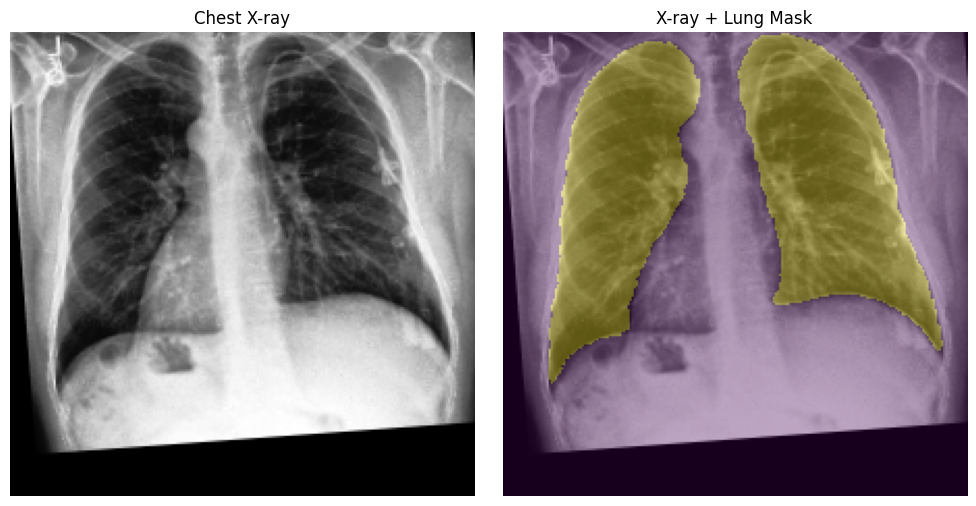

In [14]:
import matplotlib.pyplot as plt

image = images[0].cpu()
mask = masks[0].cpu()

display_image = image.mean(dim=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(display_image, cmap="gray")
axes[0].set_title("Chest X-ray")
axes[0].axis("off")

axes[1].imshow(display_image, cmap="gray")
axes[1].imshow(mask, alpha=0.35)
axes[1].set_title("X-ray + Lung Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [15]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print(
    "Allocated:",
    round(torch.cuda.memory_allocated() / 1024**2, 2),
    "MB"
)

print(
    "Reserved:",
    round(torch.cuda.memory_reserved() / 1024**2, 2),
    "MB"
)

Allocated: 0.0 MB
Reserved: 0.0 MB


In [16]:
import pytorch_lightning as pl

NUM_CLASSES = 2

LR = 1e-3
P = 0.7
D = 0.996
CUT = 1.0
CUT2 = 25.0
ISNET_A = 1.0
ISNET_B = 3.0
ISNET_E = 1.0

model = ISNetFlexLightning.ISNetFlexLgt(
    architecture="densenet121",

    heat=True,

    P=P,
    d=D,

    classes=NUM_CLASSES,

    optim="SGD",
    LR=LR,
    momentum=0.99,
    WD=0.0,
    clip=1.0,

    cut=CUT,
    cut2=CUT2,

    A=ISNET_A,
    B=ISNET_B,
    E=ISNET_E,

    selective=False,
    randomLogit=False,
    multiple=True,

    alternativeForeground="hybrid",
    norm="absRoIMean",

    HiddenLayerPenalization=False,

    pretrained=False,
    explainLabels=False,
)

print(model)

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/core/lightning.py:2065: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook


[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), ReLU()]
ISNetFlexLgt(
  (model): ISNetFlex(
    (model): DenseNet(
      (features): Sequential(
        (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu0): ReLU()
        (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (special): IgnoreIndexes()
        (denseblock1): _DenseBlock(
          (denselayer1): _DenseLayer(
            (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu1): ReLU()
            (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            

In [17]:
import pytorch_lightning as pl

NUM_CLASSES = 2

LR = 1e-3
P = 0.7
D = 0.996
CUT = 1.0
CUT2 = 25.0
A = 1.0
B = 3.0
E = 1.0

model = ISNetFlexLightning.ISNetFlexLgt(
    architecture="densenet121",

    heat=True,

    P=P,
    d=D,

    classes=NUM_CLASSES,

    optim="SGD",
    LR=LR,
    momentum=0.99,
    WD=0.0,
    clip=1.0,

    cut=CUT,
    cut2=CUT2,

    A=ISNET_A,
    B=ISNET_B,
    E=ISNET_E,

    selective=False,
    randomLogit=False,
    multiple=True,

    alternativeForeground="hybrid",
    norm="absRoIMean",

    HiddenLayerPenalization=False,

    pretrained=False,
    explainLabels=False,
)

print(model)

[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), ReLU()]
ISNetFlexLgt(
  (model): ISNetFlex(
    (model): DenseNet(
      (features): Sequential(
        (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu0): ReLU()
        (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (special): IgnoreIndexes()
        (denseblock1): _DenseBlock(
          (denselayer1): _DenseLayer(
            (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu1): ReLU()
            (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            

In [21]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

images = images.to(device)
masks = masks.to(device)
labels = labels.to(device)

print("Device:", device)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

with torch.enable_grad():

    start = time.time()

    output = model.forward(images)

    elapsed = time.time() - start

print("\nForward completed in:", round(elapsed, 3), "seconds")

print("Output type:", type(output))

if isinstance(output, dict):

    print("Output keys:", output.keys())

    logits = output["output"]

    print("Logits:", logits.shape)

    if "LRPFlex" in output:

        print(
            "LRP keys:",
            output["LRPFlex"].keys()
        )

        heatmap = output["LRPFlex"]["input"]

        print(
            "Heatmap:",
            heatmap.shape
        )
else:
    print(output)

Device: cuda

Forward completed in: 0.224 seconds
Output type: <class 'dict'>
Output keys: dict_keys(['output', 'LRPFlex'])
Logits: torch.Size([1, 2])
LRP keys: dict_keys(['input'])
Heatmap: torch.Size([1, 2, 3, 224, 224])


In [26]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("Images :", images.shape)
print("Masks  :", masks.shape)
print("Labels :", labels.shape)
print("Labels dtype:", labels.dtype)
print("Unique labels:", torch.unique(labels))

loss = model.compound_loss(
    output,
    labels,
    masks
)

print("\nLoss:", loss)
print("Loss shape:", loss.shape if hasattr(loss, "shape") else "scalar")

if torch.cuda.is_available():
    print(
        "Peak GPU memory:",
        round(
            torch.cuda.max_memory_allocated() / 1024**3,
            3
        ),
        "GB"
    )

Images : torch.Size([1, 3, 224, 224])
Masks  : torch.Size([1, 224, 224])
Labels : torch.Size([1, 1])
Labels dtype: torch.int64
Unique labels: tensor([1], device='cuda:0')

Loss: (tensor(0.6610, device='cuda:0', grad_fn=<NllLossBackward0>), tensor(2.4990, device='cuda:0', grad_fn=<DivBackward0>))
Loss shape: scalar
Peak GPU memory: 1.348 GB


/content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py:1027: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


In [27]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("Running fresh forward pass...")

start = time.time()

with torch.enable_grad():
    output = model.forward(images)

forward_time = time.time() - start

print(
    "Forward completed in:",
    round(forward_time, 3),
    "seconds"
)

classification_loss, lrp_loss = model.compound_loss(
    output,
    labels,
    masks
)

total_loss = classification_loss + lrp_loss

print("Classification loss:", classification_loss.item())
print("LRP loss:", lrp_loss.item())
print("Total loss:", total_loss.item())

print("\nStarting backward...")

start = time.time()

total_loss.backward()

backward_time = time.time() - start

print(
    "Backward completed in:",
    round(backward_time, 3),
    "seconds"
)

if torch.cuda.is_available():
    print(
        "Peak GPU memory:",
        round(
            torch.cuda.max_memory_allocated() / 1024**3,
            3
        ),
        "GB"
    )

Running fresh forward pass...
Forward completed in: 0.201 seconds
Classification loss: 0.6609529256820679
LRP loss: 2.498992919921875
Total loss: 3.1599459648132324

Starting backward...
Backward completed in: 0.74 seconds
Peak GPU memory: 2.126 GB


In [34]:
images, masks, labels = next(iter(train_loader))

print("Images:", images.shape, images.dtype)
print("Masks :", masks.shape, masks.dtype)
print("Labels:", labels.shape, labels.dtype)
print("Unique labels:", torch.unique(labels))

Images: torch.Size([1, 3, 224, 224]) torch.float32
Masks : torch.Size([1, 224, 224]) torch.float32
Labels: torch.Size([1, 1]) torch.float32
Unique labels: tensor([0.])


lightning training test  lightning's validation sanity check is disabled  to let  verify one actual training batch without introducing validation-related memory issues.

In [38]:
trainer = pl.Trainer(
    max_epochs=1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision=32,
    limit_train_batches=1,
    limit_val_batches=0,
    num_sanity_val_steps=0,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=True,
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_train_batches=1)` was configured so 1 batch per epoch will be used.


In [43]:
trainer.fit(
    model,
    train_dataloaders=train_loader
)

INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.824    Total estimated model params size (MB)


In [42]:
import time
import torch

print("Before trainer.fit()", flush=True)
print("CUDA available:", torch.cuda.is_available(), flush=True)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0), flush=True)
    torch.cuda.reset_peak_memory_stats()

start = time.time()

trainer.fit(
    model,
    train_dataloaders=train_loader
)

print(f"trainer.fit() finished in {time.time() - start:.2f}s", flush=True)

if torch.cuda.is_available():
    print(
        f"Peak GPU memory: "
        f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GB",
        flush=True
    )

Before trainer.fit()
CUDA available: True
GPU: Tesla T4


INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.824    Total estimated model params size (MB)


trainer.fit() finished in 0.12s
Peak GPU memory: 1.38 GB


In [44]:
print("Dataset length:", len(train_loader.dataset))
print("Number of batches:", len(train_loader))

try:
    batch = next(iter(train_loader))
    imgs, masks, labels = batch

    print("Batch loaded successfully")
    print("Images:", imgs.shape, imgs.dtype)
    print("Masks:", masks.shape, masks.dtype)
    print("Labels:", labels.shape, labels.dtype)

except Exception as e:
    print("Could not load a batch:")
    print(type(e).__name__, e)

Dataset length: 14740
Number of batches: 14740
Batch loaded successfully
Images: torch.Size([1, 3, 224, 224]) torch.float32
Masks: torch.Size([1, 224, 224]) torch.float32
Labels: torch.Size([1, 1]) torch.int64


In [46]:
print("Model class:", type(model))
print("Training step:", model.training_step)
print("Automatic optimization:", model.automatic_optimization)

print("\nTrainer state before fit:")
print("Training:", trainer.training)
print("State:", trainer.state)

Model class: <class 'ISNetFlexLightning.ISNetFlexLgt'>
Training step: <bound method ISNetFlexLgt.training_step of ISNetFlexLgt(
  (model): ISNetFlex(
    (model): DenseNet(
      (features): Sequential(
        (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu0): ReLU()
        (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (special): IgnoreIndexes()
        (denseblock1): _DenseBlock(
          (denselayer1): _DenseLayer(
            (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu1): ReLU()
            (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu2): ReLU()
            (conv2): Conv2d(128, 32, k

In [48]:
# a brand new trainer object
import pytorch_lightning as pl
import torch

trainer2 = pl.Trainer(
    max_epochs=1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision=32,

    # Diagnostic: only one training batch
    limit_train_batches=1,

    # Don't involve validation yet
    limit_val_batches=0,
    num_sanity_val_steps=0,

    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=True,
)

print("Starting fresh trainer...", flush=True)

trainer2.fit(
    model,
    train_dataloaders=train_loader
)

print("Training run finished.", flush=True)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_train_batches=1)` was configured so 1 batch per epoch will be used.


Starting fresh trainer...


INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.824    Total estimated model params size (MB)


Training: 0it [00:00, ?it/s]

Training run finished.


In [49]:
trainer.fit(
    model,
    train_dataloaders=train_loader
)

INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.824    Total estimated model params size (MB)


In [50]:
import inspect

print("=== training_step ===")
print(inspect.getsource(model.training_step))

print("\n=== configure_optimizers ===")
print(inspect.getsource(model.configure_optimizers))

=== training_step ===
    def training_step(self,train_batch,batch_idx):
        opt=self.optimizers()
        opt.zero_grad()
        
        inputs,masks,labels=train_batch
        
        if self.tuneCut:
            if(self.current_epoch!=self.cutEpochs):
                self.heat=False
                out=self.forward(inputs)
                loss=self.compound_loss(out,labels=labels)
            if(self.current_epoch==self.cutEpochs):
                self.heat=True
                out=self.forward(inputs)
                cLoss,hLoss,mapAbs=self.compound_loss(out,labels=labels,
                                                      masks=masks)
                #take only values from last tuning epoch
                self.updateCut(mapAbs)
                #use only for tuning cut value, ignores heatmap loss
                loss=cLoss
            
            self.log('train_loss',loss.detach(),                     
                     on_epoch=True)
        else:
            #upda

In [54]:
import inspect

print("Lightning version:", pl.__version__)
print("Model class:", type(model))
print("automatic_optimization:", model.automatic_optimization)

print("\nTrainer state BEFORE creating a new trainer:")
print(trainer.state)

Lightning version: 1.6.3
Model class: <class 'ISNetFlexLightning.ISNetFlexLgt'>
automatic_optimization: False

Trainer state BEFORE creating a new trainer:
TrainerState(status=<TrainerStatus.FINISHED: 'finished'>, fn=<TrainerFn.FITTING: 'fit'>, stage=None, _fault_tolerant_mode=<_FaultTolerantMode.DISABLED: 'disabled'>)


In [56]:
original_training_step = model.training_step

def debug_training_step(batch, batch_idx):
    print(f"\n TRAINING_STEP CALLED — batch_idx={batch_idx}", flush=True)

    result = original_training_step(batch, batch_idx)

    print(" TRAINING_STEP COMPLETED", flush=True)
    print("Returned:", result, flush=True)

    return result

model.training_step = debug_training_step

In [ ]:
trainer_test = pl.Trainer(
    max_epochs=1,
    accelerator="gpu",
    devices=1,
    precision=32,
    limit_train_batches=1,
    limit_val_batches=0,
    num_sanity_val_steps=0,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=True,
)

print("\n STARTING FIT", flush=True)

trainer_test.fit(
    model,
    train_dataloaders=train_loader
)

print("\n FIT FINISHED", flush=True)
print("Final trainer state:", trainer_test.state, flush=True)

In [58]:
print("Optimizer configuration:")

try:
    print(model.configure_optimizers())
except Exception as e:
    print("configure_optimizers ERROR:")
    print(type(e).__name__, e)

Optimizer configuration:
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.99
    nesterov: False
    weight_decay: 0.0
)


In [18]:
# testing after restarting the GPU
print("Model:", type(model))
print("Training step:", model.training_step)
print("Automatic optimization:", model.automatic_optimization)

Model: <class 'ISNetFlexLightning.ISNetFlexLgt'>
Training step: <bound method ISNetFlexLgt.training_step of ISNetFlexLgt(
  (model): ISNetFlex(
    (model): DenseNet(
      (features): Sequential(
        (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu0): ReLU()
        (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (special): IgnoreIndexes()
        (denseblock1): _DenseBlock(
          (denselayer1): _DenseLayer(
            (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu1): ReLU()
            (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu2): ReLU()
            (conv2): Conv2d(128, 32, kernel_

In [19]:
# using a lightning hook that does not modify the model's training step
def debug_train_batch_start(trainer, pl_module, batch, batch_idx):
    print(
        f"\n BATCH STARTED: batch_idx={batch_idx}",
        flush=True
    )
    print(
        f"inputs: {batch[0].shape}, "
        f"masks: {batch[1].shape}, "
        f"labels: {batch[2].shape}",
        flush=True
    )

from pytorch_lightning.callbacks import Callback

class DebugCallback(Callback):

    def on_train_batch_start(
        self,
        trainer,
        pl_module,
        batch,
        batch_idx
    ):
        print(
            f"\n TRAIN BATCH START: {batch_idx}",
            flush=True
        )

    def on_train_batch_end(
        self,
        trainer,
        pl_module,
        outputs,
        batch,
        batch_idx
    ):
        print(
            f" TRAIN BATCH END: {batch_idx}",
            flush=True
        )

In [24]:
print("model.classes:", getattr(model, "classes", None))
print("model.labelLogit:", getattr(model, "labelLogit", None))

batch = next(iter(train_loader))

images, masks, labels = batch

print("images:", images.shape, images.dtype)
print("masks :", masks.shape, masks.dtype)
print("labels:", labels.shape, labels.dtype)
print("unique labels:", torch.unique(labels))

model.classes: None
model.labelLogit: None
images: torch.Size([1, 3, 224, 224]) torch.float32
masks : torch.Size([1, 224, 224]) torch.float32
labels: torch.Size([1, 1]) torch.float32
unique labels: tensor([0.])


In [26]:
import inspect
import ISNetFlexTorch

src = inspect.getsource(ISNetFlexTorch.CompoundLoss)

# Print only the classification-loss portion
start = src.find("L['classification']")
print(src[start:start + 1200])

L['classification']=F.binary_cross_entropy_with_logits(outputs,labels)
    else:
        L['classification']=torch.nn.functional.cross_entropy(outputs,labels)
    
    if LRPFlex is not None:
        if not isinstance(LRPFlex, dict):
            LRPFlex={'input':LRPFlex}
        if not isinstance(cutFlex, dict):
            cutFlex={'input':cutFlex}
            cut2Flex={'input':cut2Flex}
            
        losses=[]
        tune={}
        for key in LRPFlex:
            if tuneCut:
                heatmapLoss,foreg=LRPLossCEValleysGWRP(LRPFlex[key],
                                                          masks,
                                                           A=A,B=B,d=d,
                                                           E=E,
                                                           rule='e',
                                                           tuneCut=tuneCut,
                                                           norm=norm,
                        

In [27]:
import ISNetFlexTorch
import inspect

print(ISNetFlexTorch.__file__)

/content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py


In [30]:
from pathlib import Path
import shutil
import ISNetFlexTorch

file_path = Path(ISNetFlexTorch.__file__)

# Create a backup
backup_path = file_path.with_suffix(".py.backup")
shutil.copy2(file_path, backup_path)

print("ISNetFlexTorch.py:")
print(file_path)
print("\nBackup:")
print(backup_path)

# Show the classification section
text = file_path.read_text()

start = text.find("if len(labels.shape)>1:")
print("\n--- Current classification code ---")
print(text[start:start+600])

ISNetFlexTorch.py:
/content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py

Backup:
/content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py.backup

--- Current classification code ---
if len(labels.shape)>1:
        labels=labels.squeeze(-1)
    if len(labels.shape)>1:
        L['classification']=F.binary_cross_entropy_with_logits(outputs,labels)
    else:
        L['classification']=torch.nn.functional.cross_entropy(outputs,labels)
    
    if LRPFlex is not None:
        if not isinstance(LRPFlex, dict):
            LRPFlex={'input':LRPFlex}
        if not isinstance(cutFlex, dict):
            cutFlex={'input':cutFlex}
            cut2Flex={'input':cut2Flex}
            
        losses=[]
        tune={}
        for key in LRPFlex:
            if tuneCut:
               


In [ ]:
# patching the function so we get   outputs [B, 1]
# labels  [B, 1] float32
#        ↓
# BCEWithLogitsLoss for our single-output pneumonia classifier
from pathlib import Path
import ISNetFlexTorch

file_path = Path(ISNetFlexTorch.__file__)

text = file_path.read_text()

old = """if len(labels.shape)>1:
        labels=labels.squeeze(-1)
    if len(labels.shape)>1:
        L['classification']=F.binary_cross_entropy_with_logits(outputs,labels)
    else:
        L['classification']=torch.nn.functional.cross_entropy(outputs,labels)"""

new = """# Binary classification: one output neuron -> BCE
    if outputs.shape[-1] == 1:
        labels = labels.float()
        if labels.dim() == 1:
            labels = labels.unsqueeze(-1)

        L['classification'] = F.binary_cross_entropy_with_logits(
            outputs, labels
        )

    # Multiclass classification -> CrossEntropy
    else:
        if labels.dim() > 1:
            labels = labels.squeeze(-1)

        labels = labels.long()

        L['classification'] = torch.nn.functional.cross_entropy(
            outputs, labels
        )"""

if old not in text:
    raise RuntimeError(
        "Expected classification block was not found. "
        "No changes were made."
    )

file_path.write_text(text.replace(old, new, 1))

print(" Classification loss patched.")
print("File:", file_path)

In [33]:
import importlib
import ISNetFlexTorch

importlib.reload(ISNetFlexTorch)

print(" Module reloaded")
print(ISNetFlexTorch.__file__)

 Module reloaded
/content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py


In [34]:
import inspect

src = inspect.getsource(ISNetFlexTorch.CompoundLoss)

start = src.find("outputs=out['output']")
print(src[start:start+1400])

outputs=out['output']
    LRPFlex=out['LRPFlex']
    
    # Binary classification: one output neuron -> BCE
    if outputs.shape[-1] == 1:
        labels = labels.float()
        if labels.dim() == 1:
            labels = labels.unsqueeze(-1)

        L['classification'] = F.binary_cross_entropy_with_logits(
            outputs, labels
        )

    # Multiclass classification -> CrossEntropy
    else:
        if labels.dim() > 1:
            labels = labels.squeeze(-1)

        labels = labels.long()

        L['classification'] = torch.nn.functional.cross_entropy(
            outputs, labels
        )
    
    if LRPFlex is not None:
        if not isinstance(LRPFlex, dict):
            LRPFlex={'input':LRPFlex}
        if not isinstance(cutFlex, dict):
            cutFlex={'input':cutFlex}
            cut2Flex={'input':cut2Flex}
            
        losses=[]
        tune={}
        for key in LRPFlex:
            if tuneCut:
                heatmapLoss,foreg=LRPLossCEValleysGWRP(L

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [38]:
images, masks, labels = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)
labels = labels.to(device)

model.eval()

out = model.forward(images)

print("\nOutput type:", type(out))

if isinstance(out, dict):
    for k, v in out.items():
        if torch.is_tensor(v):
            print(f"{k}: {v.shape}, {v.dtype}, {v.device}, requires_grad={v.requires_grad}")
        else:
            print(f"{k}: {type(v)}")


Output type: <class 'dict'>
output: torch.Size([1, 2]), torch.float32, cuda:0, requires_grad=True
LRPFlex: <class 'dict'>


In [39]:
print("labels:", labels)
print("labels shape:", labels.shape)
print("labels dtype:", labels.dtype)

print("output:", out["output"])
print("output shape:", out["output"].shape)

labels: tensor([[0.]], device='cuda:0')
labels shape: torch.Size([1, 1])
labels dtype: torch.float32
output: tensor([[ 0.0986, -0.0951]], device='cuda:0', grad_fn=<AddmmBackward0>)
output shape: torch.Size([1, 2])


In [41]:
import shutil

original_path = '/content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py'
backup_path = '/content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py.backup'

shutil.copy(backup_path, original_path)
print("Reverted ISNetFlexTorch.py to original.")

Reverted ISNetFlexTorch.py to original.


In [42]:
import importlib
import ISNetFlexTorch
importlib.reload(ISNetFlexTorch)

# confirm it's back to original by checking the classification-loss section
import inspect
src = inspect.getsource(ISNetFlexTorch)
print("shape[-1] == 2" in src)  # should print False if revert worked

False


In [43]:
import inspect
print(inspect.signature(ISNetFlexLightning.ISNetFlexLgt.__init__))

(self, model=None, architecture='densenet121', heat=True, P=0.7, d=0, optim='SGD', nesterov=False, LR=0.001, momentum=0.99, WD=0, dropLr=None, clip=1, classes=1, dropout=False, HiddenLayerPenalization=False, dLoss=1, cut=1, cut2=25, selective=False, selectiveEps=1e-07, Zb=True, e=0.01, multiple=False, randomLogit=False, pretrained=False, A=1, B=1, E=1, VGGRemoveLastMaxpool=False, alternativeForeground='hybrid', norm='absRoIMean', val='ISNet', explainLabels=False)


In [45]:
src = inspect.getsource(ISNetFlexLightning.ISNetFlexLgt.__init__)
print(src)

    def __init__(self,model=None,architecture='densenet121',
                 heat=True,P=0.7,d=0,
                 optim='SGD',nesterov=False,
                 LR=1e-3,momentum=0.99,WD=0,dropLr=None,
                 clip=1,classes=1,dropout=False,
                 HiddenLayerPenalization=False,dLoss=1,
                 cut=1,cut2=25,selective=False,selectiveEps=1e-7,Zb=True,e=0.01,
                 multiple=False,randomLogit=False,
                 pretrained=False,A=1,B=1,E=1,VGGRemoveLastMaxpool=False,
                 alternativeForeground='hybrid',
                 norm='absRoIMean',
                 val='ISNet',
                 explainLabels=False):
        """
        PyTorch Lightning module based on LRP-Flex. For Stochastic, Original and Selective ISNets.
        
        Args:
            model: arbitrary PyTorch DNN to be converted, not restricted to resnet densenet or VGG.
            If None, model is as pre-defined backbone, according to architecture parameter
         

In [46]:
src = inspect.getsource(ISNetFlexLightning.ISNetFlgt.training_step) if hasattr(ISNetFlexLightning, 'ISNetFlgt') else inspect.getsource(ISNetFlexLightning.ISNetFlexLgt.training_step)
print(src)

    def training_step(self,train_batch,batch_idx):
        opt=self.optimizers()
        opt.zero_grad()
        
        inputs,masks,labels=train_batch
        
        if self.tuneCut:
            if(self.current_epoch!=self.cutEpochs):
                self.heat=False
                out=self.forward(inputs)
                loss=self.compound_loss(out,labels=labels)
            if(self.current_epoch==self.cutEpochs):
                self.heat=True
                out=self.forward(inputs)
                cLoss,hLoss,mapAbs=self.compound_loss(out,labels=labels,
                                                      masks=masks)
                #take only values from last tuning epoch
                self.updateCut(mapAbs)
                #use only for tuning cut value, ignores heatmap loss
                loss=cLoss
            
            self.log('train_loss',loss.detach(),                     
                     on_epoch=True)
        else:
            #update dinamic P
         

In [37]:
# testing a single batch before running CompoundLoss
images, masks, labels = next(iter(train_loader))

images = images.cuda()
masks = masks.cuda()
labels = labels.cuda()

print("images:", images.shape, images.dtype)
print("masks :", masks.shape, masks.dtype)
print("labels:", labels.shape, labels.dtype)

with torch.no_grad():
    out = model.forward(images)

print("\nOutput type:", type(out))

if isinstance(out, dict):
    for k, v in out.items():
        if torch.is_tensor(v):
            print(f"{k}: {v.shape}, {v.dtype}")
        else:
            print(f"{k}: {type(v)}")

images: torch.Size([1, 3, 224, 224]) torch.float32
masks : torch.Size([1, 224, 224]) torch.float32
labels: torch.Size([1, 1]) torch.float32


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [23]:
trainer_test = pl.Trainer(
    max_epochs=1,
    accelerator="gpu",
    devices=1,
    precision=32,
    limit_train_batches=1,
    limit_val_batches=0,
    num_sanity_val_steps=0,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=True,
    callbacks=[DebugCallback()],
)

print(" STARTING FIT", flush=True)

trainer_test.fit(
    model,
    train_dataloaders=train_loader
)

print(" FIT FINISHED", flush=True)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_train_batches=1)` was configured so 1 batch per epoch will be used.


 STARTING FIT


INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.824    Total estimated model params size (MB)


Training: 0it [00:00, ?it/s]


 TRAIN BATCH START: 0


NotImplementedError: "nll_loss_forward_reduce_cuda_kernel_2d_index" not implemented for 'Float'

restarted testing to reduce mismatches in code and get a cleaner notebook

In [11]:
# environment and CUDA setup
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import gc
import time
import inspect
import traceback
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Environment ready.")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB
Environment ready.


In [18]:
import shutil
import sys
from pathlib import Path

ISNET_CODE = Path("/content/drive/MyDrive/MediScan_AI/ISNet_repo/code")

if not ISNET_CODE.exists():
    raise FileNotFoundError(f"ISNet code directory not found:\n{ISNET_CODE}")

original_path = ISNET_CODE / "ISNetFlexTorch.py"
backup_path = ISNET_CODE / "ISNetFlexTorch.py.backup"

if backup_path.exists():
    shutil.copy(backup_path, original_path)
    print("Reverted ISNetFlexTorch.py to original from backup.")
else:
    print("No backup found — assuming file is already in original state.")

if str(ISNET_CODE) not in sys.path:
    sys.path.insert(0, str(ISNET_CODE))

import LRPDenseNetZe
import ISNetFlexTorch
import ISNetFlexLightning

print("Imported: LRPDenseNetZe, ISNetFlexTorch, ISNetFlexLightning")

src = inspect.getsource(ISNetFlexTorch)
print("\nPatch present ('shape[-1] == 2'):", "shape[-1] == 2" in src, "— should be False")


Reverted ISNetFlexTorch.py to original from backup.
Imported: LRPDenseNetZe, ISNetFlexTorch, ISNetFlexLightning

Patch present ('shape[-1] == 2'): False — should be False


In [19]:
# dataset verification
required = ["train_dataset", "val_dataset", "test_dataset"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError("Missing: " + ", ".join(missing))
print("Dataset sizes:", len(train_dataset), len(val_dataset), len(test_dataset))



Dataset sizes: 14740 1840 1816


In [12]:
# Safe ISNet dataset wrapper
from torch.utils.data import Dataset

class ISNetDatasetWrapper(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
    def __len__(self):
        return len(self.base_dataset)
    def __getitem__(self, idx):
        image, mask, label = self.base_dataset[idx]
        image = torch.as_tensor(image).float()
        if image.ndim == 2:
            image = image.unsqueeze(0)
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)
        mask = torch.as_tensor(mask).float()
        if mask.ndim == 3 and mask.shape[0] == 1:
            mask = mask.squeeze(0)
        if mask.ndim == 3 and mask.shape[0] == 3:
            mask = mask.mean(dim=0)
        mask = (mask > 0.5).float()
        label = torch.as_tensor(label).float()
        if label.ndim == 0:
            label = label.unsqueeze(0)
        return image, mask, label

isnet_train_dataset = ISNetDatasetWrapper(train_dataset)
isnet_val_dataset   = ISNetDatasetWrapper(val_dataset)
isnet_test_dataset  = ISNetDatasetWrapper(test_dataset)
print("Wrapped:", len(isnet_train_dataset), len(isnet_val_dataset), len(isnet_test_dataset))

Wrapped: 14740 1840 1816


In [13]:
# ISNet DataLoaders (BATCH_SIZE = 1)
BATCH_SIZE = 1
train_loader = DataLoader(isnet_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(isnet_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(isnet_test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
images, masks, labels = next(iter(train_loader))
print("Image :", images.shape)
print("Mask  :", masks.shape)
print("Label :", labels.shape)

Image : torch.Size([1, 3, 224, 224])
Mask  : torch.Size([1, 224, 224])
Label : torch.Size([1, 1])


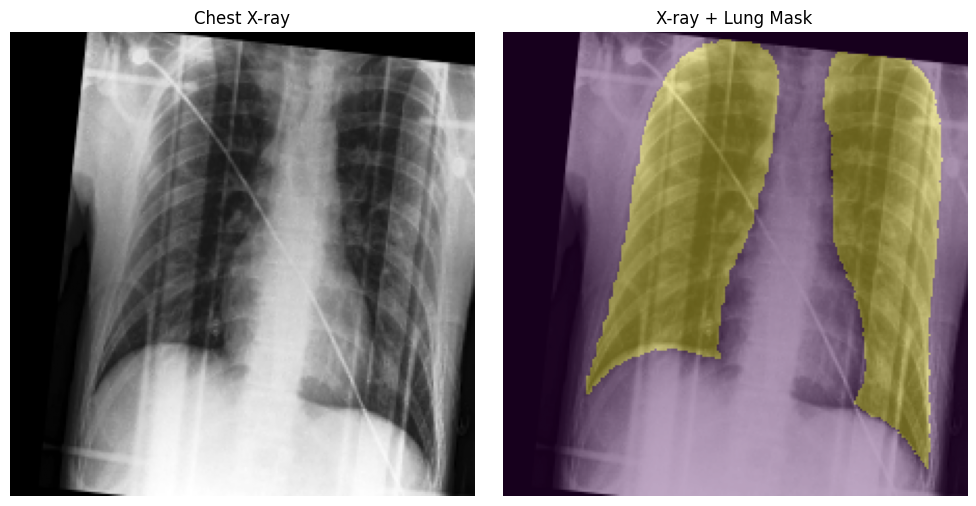

In [13]:
# inspect image + mask
import matplotlib.pyplot as plt

image = images[0].cpu()
mask = masks[0].cpu()
display_image = image.mean(dim=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(display_image, cmap="gray")
axes[0].set_title("Chest X-ray")
axes[0].axis("off")
axes[1].imshow(display_image, cmap="gray")
axes[1].imshow(mask, alpha=0.35)
axes[1].set_title("X-ray + Lung Mask")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [14]:
# GPU memory cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("Allocated:", round(torch.cuda.memory_allocated() / 1024**2, 2), "MB")
print("Reserved:", round(torch.cuda.memory_reserved() / 1024**2, 2), "MB")

Allocated: 0.0 MB
Reserved: 0.0 MB


In [22]:
# Build Faster ISNet (classes=1)
import pytorch_lightning as pl

NUM_CLASSES = 1
LR = 1e-3
P = 0.7
D = 0.996
CUT = 1
CUT2 = 25
A_PARAM = 1
B_PARAM = 3
E_PARAM = 1

model = ISNetFlexLightning.ISNetFlexLgt(
    architecture="densenet121",
    heat=True,
    P=P,
    d=D,
    classes=NUM_CLASSES,
    optim="SGD",
    LR=LR,
    momentum=0.99,
    WD=0.0,
    clip=1,
    cut=CUT,
    cut2=CUT2,
    A=A_PARAM,
    B=B_PARAM,
    E=E_PARAM,
    selective=False,
    randomLogit=False,
    multiple=True,
    alternativeForeground="hybrid",
    norm="absRoIMean",
    HiddenLayerPenalization=False,
    pretrained=False,
    explainLabels=False,
)
print("Model built. Classifier output features:", model.model.model.classifier.out_features)



[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), ReLU()]
Model built. Classifier output features: 1


In [23]:
# Model forward test — checking output shape explicitly this time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
images, masks, labels = images.to(device), masks.to(device), labels.to(device)

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

output = model.forward(images)
print("Output keys:", output.keys())
print("Logits shape:", output['output'].shape)


Output keys: dict_keys(['output', 'LRPFlex'])
Logits shape: torch.Size([1, 1])


In [24]:
# memory measurement
if torch.cuda.is_available():

    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    peak = torch.cuda.max_memory_allocated() / 1024**2

    print(f"Current allocated : {allocated:.2f} MB")
    print(f"Current reserved  : {reserved:.2f} MB")
    print(f"Peak allocated    : {peak:.2f} MB")

Current allocated : 501.22 MB
Current reserved  : 536.00 MB
Peak allocated    : 519.27 MB


In [25]:
# Test ISNet loss
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

model.train()

start = time.time()

output = model.forward(images)

classification_loss, heatmap_loss = model.compound_loss(
    output,
    labels=labels,
    masks=masks,
)

loss = (
    (1 - model.P) * classification_loss
    + model.P * heatmap_loss
)

elapsed = time.time() - start

print("Loss calculation completed.")
print("Time:", round(elapsed, 3), "seconds")

print(
    "Classification loss:",
    classification_loss.detach().float().item()
)

print(
    "Heatmap loss:",
    heatmap_loss.detach().float().item()
)

print(
    "Combined loss:",
    loss.detach().float().item()
)

if torch.cuda.is_available():
    print(
        "Peak GPU memory:",
        round(torch.cuda.max_memory_allocated() / 1024**2, 2),
        "MB"
    )

NotImplementedError: "nll_loss_forward_reduce_cuda_kernel_2d_index" not implemented for 'Float'

In [26]:
# inspecting CompoundLoss
import inspect
import ISNetFlexTorch

print(inspect.getsource(ISNetFlexTorch.CompoundLoss))

def CompoundLoss(out,labels,masks=None,
                 tuneCut=False,d=1,dLoss=1,cutFlex=None,cut2Flex=None,
                 A=1,B=1,E=1,
                 alternativeForeground=False,norm=True):
    """
    Function to apply the ISNet loss, with option of LRP deep supervision (LDS).
    
    Args:
        out:DNN output, dictionaty with logits ('output') and LRP heatmaps ('LRPFlex')
        For LDS, heatmaps are another dictionary, with heatmaps for every supervised layer
        labels: labels
        masks: foreground segmentation masks, valued 1 in foreground and 0 in background
        tuneCut: if True, loss outputs total absolute relevance for selection of C1 and C2 
        hyper-parameters, use for non-ISNet only
        d: background loss GWRP exponential decay
        dLoss: LDS exponential decay (GWRP)
        cutFlex,cut2Flex: C1 and C2 hyper-parameters
        A and B: w1 and w2 parameters, weights for the background and foreground loss
        E: parameter of the backgr

In [27]:
#  patching the module 

from pathlib import Path
import shutil
import importlib
import ISNetFlexTorch

# --------------------------------------------------
# 1. Locate the module
# --------------------------------------------------
module_path = Path(ISNetFlexTorch.__file__)
print("Patching:", module_path)

# --------------------------------------------------
# 2. Create a safety backup
# --------------------------------------------------
backup_path = module_path.with_suffix(".py.before_bce_patch")

if not backup_path.exists():
    shutil.copy2(module_path, backup_path)
    print("Backup created:", backup_path)
else:
    print("Backup already exists:", backup_path)

# --------------------------------------------------
# 3. Read the current source
# --------------------------------------------------
source = module_path.read_text()

old_block = """    if len(labels.shape)>1:
        labels=labels.squeeze(-1)
    if len(labels.shape)>1:
        L['classification']=F.binary_cross_entropy_with_logits(outputs,labels)
    else:
        L['classification']=torch.nn.functional.cross_entropy(outputs,labels)
"""

new_block = """    if outputs.shape[-1] == 1:
        labels = labels.float()

        if labels.dim() == 1:
            labels = labels.unsqueeze(-1)

        L['classification'] = F.binary_cross_entropy_with_logits(
            outputs,
            labels
        )
    else:
        if labels.dim() > 1:
            labels = labels.squeeze(-1)

        labels = labels.long()

        L['classification'] = F.cross_entropy(
            outputs,
            labels
        )
"""

# --------------------------------------------------
# 4. Make sure to patch the exact code
# --------------------------------------------------
if old_block not in source:
    raise RuntimeError(
        "The expected original classification block was not found. "
        "No changes were made."
    )

# --------------------------------------------------
# 5. Apply ONLY this patch
# --------------------------------------------------
patched_source = source.replace(old_block, new_block, 1)

module_path.write_text(patched_source)

print("Classification-loss patch applied successfully.")

# --------------------------------------------------
# 6. Reload the Python module
# --------------------------------------------------
importlib.reload(ISNetFlexTorch)

print("ISNetFlexTorch reloaded.")

# --------------------------------------------------
# 7. Verify the patch
# --------------------------------------------------
src = inspect.getsource(ISNetFlexTorch.CompoundLoss)

print("\nPatched classification section:")
start = src.find("outputs=out['output']")
end = src.find("if LRPFlex is not None:")

print(src[start:end])

Patching: /content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py
Backup created: /content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py.before_bce_patch
Classification-loss patch applied successfully.
ISNetFlexTorch reloaded.

Patched classification section:
outputs=out['output']
    LRPFlex=out['LRPFlex']
    
    if outputs.shape[-1] == 1:
        labels = labels.float()

        if labels.dim() == 1:
            labels = labels.unsqueeze(-1)

        L['classification'] = F.binary_cross_entropy_with_logits(
            outputs,
            labels
        )
    else:
        if labels.dim() > 1:
            labels = labels.squeeze(-1)

        labels = labels.long()

        L['classification'] = F.cross_entropy(
            outputs,
            labels
        )
    
    


In [28]:
# re-Test ISNet loss
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

model.train()

start = time.time()

output = model.forward(images)

classification_loss, heatmap_loss = model.compound_loss(
    output,
    labels=labels,
    masks=masks,
)

loss = (
    (1 - model.P) * classification_loss
    + model.P * heatmap_loss
)

elapsed = time.time() - start

print("Loss calculation completed.")
print("Time:", round(elapsed, 3), "seconds")

print(
    "Classification loss:",
    classification_loss.detach().float().item()
)

print(
    "Heatmap loss:",
    heatmap_loss.detach().float().item()
)

print(
    "Combined loss:",
    loss.detach().float().item()
)

if torch.cuda.is_available():
    print(
        "Peak GPU memory:",
        round(torch.cuda.max_memory_allocated() / 1024**2, 2),
        "MB"
    )

/content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py:1041: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Loss calculation completed.
Time: 0.384 seconds
Classification loss: 0.7417082786560059
Heatmap loss: 2.2689151763916016
Combined loss: 1.8107531070709229
Peak GPU memory: 1316.03 MB


In [29]:
# single batch backward memory test
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

model.train()

for p in model.parameters():
    p.grad = None

print("Starting single-batch backward test...")

try:

    start = time.time()

    output = model.forward(images)

    cLoss, hLoss = model.compound_loss(
        output,
        labels=labels,
        masks=masks,
    )

    loss = (
        (1 - model.P) * cLoss
        + model.P * hLoss
    )

    print(
        "Loss:",
        loss.detach().float().item()
    )

    loss.backward()

    elapsed = time.time() - start

    print("\nBACKWARD PASSED")
    print("Time:", round(elapsed, 3), "seconds")

    if torch.cuda.is_available():
        print(
            "Peak GPU memory:",
            round(
                torch.cuda.max_memory_allocated() / 1024**2,
                2
            ),
            "MB"
        )

except torch.cuda.OutOfMemoryError:

    print("\n!!! CUDA OUT OF MEMORY DURING BACKWARD !!!")

    if torch.cuda.is_available():
        print(
            "Peak GPU memory:",
            round(
                torch.cuda.max_memory_allocated() / 1024**2,
                2
            ),
            "MB"
        )

    raise

finally:

    for p in model.parameters():
        p.grad = None

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Starting single-batch backward test...
Loss: 1.8107531070709229

BACKWARD PASSED
Time: 0.966 seconds
Peak GPU memory: 1828.38 MB


In [33]:
# One-epoch Lightning sanity test (Trainer setup) — includes gradient accumulation
from pytorch_lightning.callbacks import ModelCheckpoint

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=1,
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
    precision="32",
    num_sanity_val_steps=0,
    limit_val_batches=1,
    logger=False,
    enable_checkpointing=False,
    deterministic=True,
    accumulate_grad_batches=16,
)

print("Trainer ready.")

RuntimeError: No precision set

In [34]:
import pytorch_lightning as pl
import torch
import inspect

print("PyTorch:", torch.__version__)
print("PyTorch Lightning:", pl.__version__)
print("Python:", __import__("sys").version)

print("\nTrainer precision-related defaults:")
sig = inspect.signature(pl.Trainer)
print(sig.parameters["precision"])

print("\nLightning module path:")
print(pl.__file__)

PyTorch: 2.11.0+cu128
PyTorch Lightning: 1.6.3
Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]

Trainer precision-related defaults:
precision: Union[int, str] = 32

Lightning module path:
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/__init__.py


In [35]:
import pytorch_lightning as pl

trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=1,
    precision=32,
    logger=False,
    enable_checkpointing=False,
)

print("Basic Trainer created successfully.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Basic Trainer created successfully.


In [36]:
trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=1,
    precision=32,
    logger=False,
    enable_checkpointing=False,
    accumulate_grad_batches=16,
)

print("Trainer with gradient accumulation created successfully.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Trainer with gradient accumulation created successfully.


In [37]:
trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=1,
    precision=32,
    logger=False,
    enable_checkpointing=False,
    accumulate_grad_batches=16,
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
)

print("Trainer with accumulation + gradient clipping created successfully.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Trainer with accumulation + gradient clipping created successfully.


In [38]:
trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=1,
    precision=32,
    logger=False,
    enable_checkpointing=False,
    accumulate_grad_batches=16,
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
    num_sanity_val_steps=0,
    limit_val_batches=1,
)

print("Trainer ready.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_val_batches=1)` was configured so 1 batch will be used.


Trainer ready.


In [39]:
# 1 epoch / 1 batch sanity run
print("Starting Lightning sanity run...")

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

print("Sanity training completed.")

Starting Lightning sanity run...


MisconfigurationException: Automatic gradient clipping is not supported for manual optimization. Remove `Trainer(gradient_clip_val=1.0)` or switch to automatic optimization.

In [40]:
# updated trainer
trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=1,
    precision=32,
    logger=False,
    enable_checkpointing=False,
    accumulate_grad_batches=16,
    num_sanity_val_steps=0,
    limit_val_batches=1,
)

print("Trainer ready.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_val_batches=1)` was configured so 1 batch will be used.


Trainer ready.


In [41]:
trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

MisconfigurationException: Automatic gradient accumulation is not supported for manual optimization. Remove `Trainer(accumulate_grad_batches=16)` or switch to automatic optimization.

In [42]:
# removing both automatic mechanisms
trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=1,
    precision=32,
    logger=False,
    enable_checkpointing=False,
    num_sanity_val_steps=0,
    limit_val_batches=1,
)

print("Trainer ready.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_val_batches=1)` was configured so 1 batch will be used.


Trainer ready.


In [43]:
trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.820    Total estimated model params size (MB)


Training: 0it [00:00, ?it/s]

: 

kernel got disconnected and model state was lost an updated trainer cell with checkpoints is below  to avoid a future occurence of the same incident


current workflow

Kernel starts
    ↓
Mount Google Drive
    ↓
Run imports
    ↓
Load dataset/dataloaders
    ↓
Build SAME ISNet model
    ↓
Create checkpointed Trainer
    ↓
Find latest checkpoint
    ↓
trainer.fit()
    ↓
 ┌───────────────────────┐
 │ checkpoint every 500  │
 │ steps + last.ckpt     │
 └───────────────────────┘
    ↓
Kernel disconnects?
    ↓
Restart kernel
    ↓
Run setup again
    ↓
Find last.ckpt
    ↓
Resume training

In [15]:
# Build Faster ISNet (classes=1)
import pytorch_lightning as pl

NUM_CLASSES = 1
LR = 1e-3
P = 0.7
D = 0.996
CUT = 1
CUT2 = 25
A_PARAM = 1
B_PARAM = 3
E_PARAM = 1

model = ISNetFlexLightning.ISNetFlexLgt(
    architecture="densenet121",
    heat=True,
    P=P,
    d=D,
    classes=NUM_CLASSES,
    optim="SGD",
    LR=LR,
    momentum=0.99,
    WD=0.0,
    clip=1,
    cut=CUT,
    cut2=CUT2,
    A=A_PARAM,
    B=B_PARAM,
    E=E_PARAM,
    selective=False,
    randomLogit=False,
    multiple=True,
    alternativeForeground="hybrid",
    norm="absRoIMean",
    HiddenLayerPenalization=False,
    pretrained=False,
    explainLabels=False,
)
print("Model built. Classifier output features:", model.model.model.classifier.out_features)



/usr/local/lib/python3.13/dist-packages/pytorch_lightning/core/lightning.py:2065: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook


[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), ReLU()]
Model built. Classifier output features: 1


In [16]:
# Checkpointed Lightning Trainer
from pathlib import Path
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia"
)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(CHECKPOINT_DIR),
    filename="isnet-{epoch:02d}-step-{step}",
    every_n_train_steps=500,
    save_top_k=-1,
    save_last=True,
)

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=1,
    precision=32,
    logger=False,
    enable_checkpointing=True,
    callbacks=[checkpoint_callback],
    num_sanity_val_steps=0,
    limit_val_batches=1,
)

print("Checkpointed Trainer ready.")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

INFO:pytorch_lightning.utilities.rank_zero:ModelCheckpoint(save_last=True, save_top_k=-1, monitor=None) will duplicate the last checkpoint saved.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_val_batches=1)` was configured so 1 batch will be used.


Checkpointed Trainer ready.
Checkpoint directory: /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia


In [17]:
# Find the latest checkpoint automatically

from pathlib import Path

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia"
)

last_checkpoint = CHECKPOINT_DIR / "last.ckpt"

if last_checkpoint.exists():
    resume_checkpoint = last_checkpoint
    print(f"Found last checkpoint:")
    print(resume_checkpoint)
else:
    checkpoints = list(CHECKPOINT_DIR.glob("*.ckpt"))

    if checkpoints:
        resume_checkpoint = max(
            checkpoints,
            key=lambda p: p.stat().st_mtime
        )
        print("No last.ckpt found.")
        print("Using most recently modified checkpoint:")
        print(resume_checkpoint)
    else:
        resume_checkpoint = None
        print("No checkpoints found.")
        print("Training will start from scratch.")

No checkpoints found.
Training will start from scratch.


In [18]:
print("Starting Lightning training...")

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    ckpt_path=str(resume_checkpoint) if resume_checkpoint else None,
)

INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.820    Total estimated model params size (MB)


Starting Lightning training...


Training: 0it [00:00, ?it/s]

/content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py:1041: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/trainer.py:724: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


In [19]:
from pathlib import Path

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia"
)

print("Checkpoint directory exists:", CHECKPOINT_DIR.exists())

if CHECKPOINT_DIR.exists():
    checkpoints = sorted(
        CHECKPOINT_DIR.glob("*.ckpt"),
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )

    print(f"Checkpoints found: {len(checkpoints)}")

    for ckpt in checkpoints:
        print(
            f"- {ckpt.name} | "
            f"{ckpt.stat().st_size / (1024**2):.2f} MB"
        )
else:
    print("Checkpoint directory does not exist yet.")

Checkpoint directory exists: True
Checkpoints found: 3
- last.ckpt | 53.76 MB
- isnet-epoch=00-step-step=1000.ckpt | 53.76 MB
- isnet-epoch=00-step-step=500.ckpt | 53.76 MB


In [20]:
import torch
from pathlib import Path

last_checkpoint = Path(
    "/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt"
)

print("Loading checkpoint metadata...")
ckpt = torch.load(
    last_checkpoint,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint loaded successfully.")
print()

print("Epoch:", ckpt.get("epoch"))
print("Global step:", ckpt.get("global_step"))

print()
print("Checkpoint keys:")
print(list(ckpt.keys()))

Loading checkpoint metadata...
Checkpoint loaded successfully.

Epoch: 0
Global step: 1000

Checkpoint keys:
['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters']


In [21]:
# ============================================================
# Lightning Trainer with visible progress bar
# ============================================================

from pytorch_lightning.callbacks import ModelCheckpoint, TQDMProgressBar

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia"
)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(CHECKPOINT_DIR),
    filename="isnet-{epoch:02d}-{step}",
    every_n_train_steps=500,
    save_top_k=-1,
    save_last=True,
)

progress_bar = TQDMProgressBar(
    refresh_rate=10
)

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=1,
    precision=32,
    logger=False,
    enable_checkpointing=True,
    callbacks=[
        checkpoint_callback,
        progress_bar,
    ],
    num_sanity_val_steps=0,
    limit_val_batches=1,
)

print("Trainer ready.")
print("Progress bar: enabled")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

INFO:pytorch_lightning.utilities.rank_zero:ModelCheckpoint(save_last=True, save_top_k=-1, monitor=None) will duplicate the last checkpoint saved.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_val_batches=1)` was configured so 1 batch will be used.


Trainer ready.
Progress bar: enabled
Checkpoint directory: /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia


In [22]:
resume_checkpoint = CHECKPOINT_DIR / "last.ckpt"

print("Resuming from:")
print(resume_checkpoint)

Resuming from:
/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt


In [23]:
print("Resuming Lightning training...")

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    ckpt_path=str(resume_checkpoint),
)

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:611: UserWarning: Checkpoint directory /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt


Resuming Lightning training...


INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.820    Total estimated model params size (MB)
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint file at /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt


Training: 1000it [00:00, ?it/s]

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/loops/epoch/training_epoch_loop.py:135: UserWarning: You're resuming from a checkpoint that ended before the epoch ended. This can cause unreliable results if further training is done. Consider using an end-of-epoch checkpoint or enabling fault-tolerant training: https://pytorch-lightning.readthedocs.io/en/stable/advanced/fault_tolerant_training.html
  rank_zero_warn(


: 

In [ ]:
from pathlib import Path
import torch
from datetime import datetime

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia"
)

print("Checkpoint status:")
print("-" * 50)

for ckpt in sorted(CHECKPOINT_DIR.glob("*.ckpt")):
    modified = datetime.fromtimestamp(ckpt.stat().st_mtime)

    print(f"{ckpt.name}")
    print(f"  Modified: {modified}")
    print(f"  Size:     {ckpt.stat().st_size / (1024**2):.2f} MB")

    if ckpt.name == "last.ckpt":
        data = torch.load(
            ckpt,
            map_location="cpu",
            weights_only=False
        )
        print(f"  Epoch:    {data.get('epoch')}")
        print(f"  Step:     {data.get('global_step')}")

    print()

resuming after disconnects

In [8]:
NUM_CLASSES = 1

LR = 1e-3
P = 0.7
D = 0.996

CUT = 1
CUT2 = 25

A_PARAM = 1
B_PARAM = 3
E_PARAM = 1

model = ISNetFlexLightning.ISNetFlexLgt(
    architecture="densenet121",
    heat=True,
    P=P,
    d=D,
    classes=NUM_CLASSES,
    optim="SGD",
    LR=LR,
    momentum=0.99,
    WD=0.0,
    clip=1,
    cut=CUT,
    cut2=CUT2,
    A=A_PARAM,
    B=B_PARAM,
    E=E_PARAM,
    selective=False,
    randomLogit=False,
    multiple=True,
    alternativeForeground="hybrid",
    norm="absRoIMean",
    HiddenLayerPenalization=False,
    pretrained=False,
    explainLabels=False,
)

print("Model recreated.")
print("Classifier output features:",
      model.model.model.classifier.out_features)

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/core/lightning.py:2065: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook


[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), ReLU()]
Model recreated.
Classifier output features: 1


In [9]:
# ============================================================
# ISNet — Checkpointed Lightning Trainer
# ============================================================

from pathlib import Path
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, TQDMProgressBar


# ------------------------------------------------------------
# 1. Checkpoint directory
# ------------------------------------------------------------

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia"
)

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Checkpoint directory:")
print(CHECKPOINT_DIR)
print("Exists:", CHECKPOINT_DIR.exists())


# ------------------------------------------------------------
# 2. Checkpoint callback
# ------------------------------------------------------------

checkpoint_callback = ModelCheckpoint(
    dirpath=str(CHECKPOINT_DIR),

    # Save checkpoints with epoch + global step
    filename="isnet-{epoch:02d}-step-{step}",

    # Save every 500 training steps
    every_n_train_steps=500,

    # Keep all periodic checkpoints
    save_top_k=-1,

    # Always maintain last.ckpt
    save_last=True,
)


# ------------------------------------------------------------
# 3. Progress bar
# ------------------------------------------------------------

progress_bar = TQDMProgressBar(
    refresh_rate=10
)


# ------------------------------------------------------------
# 4. Create Trainer
# ------------------------------------------------------------

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,

    max_epochs=1,

    # Lightning 1.6.3 + this ISNet implementation
    precision=32,

    logger=False,

    enable_checkpointing=True,

    callbacks=[
        checkpoint_callback,
        progress_bar,
    ],

    # Avoid validation sanity-check before training
    num_sanity_val_steps=0,

    # Only one validation batch when validation runs
    limit_val_batches=1,
)


print()
print("Trainer ready.")
print("GPU available:", torch.cuda.is_available())
print("Checkpoint directory:", CHECKPOINT_DIR)

INFO:pytorch_lightning.utilities.rank_zero:ModelCheckpoint(save_last=True, save_top_k=-1, monitor=None) will duplicate the last checkpoint saved.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_val_batches=1)` was configured so 1 batch will be used.


Checkpoint directory:
/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia
Exists: True

Trainer ready.
GPU available: True
Checkpoint directory: /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia


In [10]:
# ============================================================
# Inspect the latest checkpoint
# ============================================================

last_checkpoint = CHECKPOINT_DIR / "last.ckpt"

if last_checkpoint.exists():

    print("Found last.ckpt:")
    print(last_checkpoint)

    ckpt = torch.load(
        last_checkpoint,
        map_location="cpu",
        weights_only=False
    )

    print()
    print("Checkpoint information:")
    print("Epoch:", ckpt.get("epoch"))
    print("Global step:", ckpt.get("global_step"))

else:
    print("WARNING: last.ckpt was not found.")

Found last.ckpt:
/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt

Checkpoint information:
Epoch: 0
Global step: 3000


In [11]:
# ============================================================
# Resume ISNet training from step 3000
# ============================================================

resume_checkpoint = CHECKPOINT_DIR / "last.ckpt"

print("Resuming from:")
print(resume_checkpoint)
print()
print("Expected checkpoint:")
print("Epoch:", 0)
print("Global step:", 3000)

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    ckpt_path=str(resume_checkpoint),
)

Resuming from:
/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt

Expected checkpoint:
Epoch: 0
Global step: 3000


/usr/local/lib/python3.13/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:611: UserWarning: Checkpoint directory /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt
INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.820    Total estimated model params size (MB)
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint file at /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumon

Training: 2999it [00:00, ?it/s]

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/loops/epoch/training_epoch_loop.py:135: UserWarning: You're resuming from a checkpoint that ended before the epoch ended. This can cause unreliable results if further training is done. Consider using an end-of-epoch checkpoint or enabling fault-tolerant training: https://pytorch-lightning.readthedocs.io/en/stable/advanced/fault_tolerant_training.html
  rank_zero_warn(
/content/drive/MyDrive/MediScan_AI/ISNet_repo/code/ISNetFlexTorch.py:1041: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


In [12]:
print("Trainer state before fit:")
print("Current epoch:", trainer.current_epoch)
print("Global step:", trainer.global_step)

print("\nRunning resume...")

Trainer state before fit:
Current epoch: 1
Global step: 3001

Running resume...


In [13]:
resume_checkpoint = CHECKPOINT_DIR / "last.ckpt"

print("Starting trainer.fit()...")

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    ckpt_path=str(resume_checkpoint),
)

print("\nTRAINER.FIT() FINISHED")
print("Final epoch:", trainer.current_epoch)
print("Final global step:", trainer.global_step)

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt


Starting trainer.fit()...


INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.820    Total estimated model params size (MB)
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint file at /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt



TRAINER.FIT() FINISHED
Final epoch: 1
Final global step: 3001


In [14]:
last_checkpoint = CHECKPOINT_DIR / "last.ckpt"

ckpt = torch.load(
    last_checkpoint,
    map_location="cpu",
    weights_only=False
)

print("Epoch:", ckpt.get("epoch"))
print("Global step:", ckpt.get("global_step"))

Epoch: 0
Global step: 3001


In [15]:
print("Progress callback:")
print(progress_bar)

print("\nTrainer callbacks:")
for cb in trainer.callbacks:
    print(type(cb).__name__)

Progress callback:

Trainer callbacks:
TQDMProgressBar
ModelSummary
GradientAccumulationScheduler
ModelCheckpoint


In [16]:
from tqdm.auto import tqdm
import time

for i in tqdm(range(20), desc="Progress test"):
    time.sleep(0.2)

Progress test:   0%|          | 0/20 [00:00<?, ?it/s]

In [17]:
print("Trainer callbacks:")
for i, cb in enumerate(trainer.callbacks):
    print(i, type(cb).__name__)

print("\nProgress bar object:")
print(progress_bar)

print("\nTrainer progress bar enabled:")
print(getattr(progress_bar, "is_enabled", "attribute not found"))

Trainer callbacks:
0 TQDMProgressBar
1 ModelSummary
2 GradientAccumulationScheduler
3 ModelCheckpoint

Progress bar object:

Trainer progress bar enabled:
True


In [18]:
pb = trainer.progress_bar_callback

print("Progress bar class:", type(pb).__name__)
print("Enabled:", pb.is_enabled)
print("Refresh rate:", pb.refresh_rate)
print("Leave:", pb.leave)

print("\nTrainer progress callback:", type(trainer.progress_bar_callback).__name__)

print("\nTrainer state:")
print("Current epoch:", trainer.current_epoch)
print("Global step:", trainer.global_step)

Progress bar class: TQDMProgressBar
Enabled: True
Refresh rate: 10


AttributeError: 'TQDMProgressBar' object has no attribute 'leave'

In [19]:
pb = trainer.progress_bar_callback

print("Progress bar class:", type(pb).__name__)
print("Enabled:", pb.is_enabled)
print("Refresh rate:", pb.refresh_rate)

print("\nTrainer progress callback:", type(trainer.progress_bar_callback).__name__)

print("\nTrainer state:")
print("Current epoch:", trainer.current_epoch)
print("Global step:", trainer.global_step)

print("\nProgress bar attributes:")
print(vars(pb).keys())

Progress bar class: TQDMProgressBar
Enabled: True
Refresh rate: 10

Trainer progress callback: TQDMProgressBar

Trainer state:
Current epoch: 1
Global step: 3001

Progress bar attributes:
dict_keys(['_trainer', '_current_eval_dataloader_idx', '_refresh_rate', '_process_position', '_enabled', '_main_progress_bar', '_val_progress_bar', '_test_progress_bar', '_predict_progress_bar', 'log', 'log_dict'])


In [20]:
import sys

print("stdout:", type(sys.stdout))
print("stderr:", type(sys.stderr))
print("stdout isatty:", sys.stdout.isatty())
print("stderr isatty:", sys.stderr.isatty())

stdout: <class 'ipykernel.iostream.OutStream'>
stderr: <class 'ipykernel.iostream.OutStream'>
stdout isatty: False
stderr isatty: False


In [21]:
import inspect
from pytorch_lightning.callbacks import TQDMProgressBar

print(inspect.getsource(TQDMProgressBar.init_train_tqdm))

    def init_train_tqdm(self) -> Tqdm:
        """Override this to customize the tqdm bar for training."""
        bar = Tqdm(
            desc=self.train_description,
            initial=self.train_batch_idx,
            position=(2 * self.process_position),
            disable=self.is_disabled,
            leave=True,
            dynamic_ncols=True,
            file=sys.stdout,
            smoothing=0,
        )
        return bar



In [22]:
from pytorch_lightning.callbacks import TQDMProgressBar
from tqdm.auto import tqdm


class NotebookTQDMProgressBar(TQDMProgressBar):

    def init_train_tqdm(self):
        bar = tqdm(
            desc=self.train_description,
            initial=self.train_batch_idx,
            total=self.total_train_batches,
            position=self.process_position,
            disable=self.is_disabled,
            leave=True,
            dynamic_ncols=True,
            smoothing=0,
        )
        return bar

    def init_validation_tqdm(self):
        bar = tqdm(
            desc=self.validation_description,
            initial=0,
            total=self.total_val_batches,
            position=self.process_position + 1,
            disable=self.is_disabled,
            leave=False,
            dynamic_ncols=True,
            smoothing=0,
        )
        return bar

In [23]:
notebook_progress = NotebookTQDMProgressBar(refresh_rate=10)

print("Callback:", type(notebook_progress).__name__)
print("Enabled:", notebook_progress.is_enabled)
print("Refresh rate:", notebook_progress.refresh_rate)

Callback: NotebookTQDMProgressBar
Enabled: True
Refresh rate: 10


In [24]:
test_progress_bar = NotebookTQDMProgressBar(refresh_rate=1)

test_checkpoint = ModelCheckpoint(
    dirpath=str(CHECKPOINT_DIR),
    filename="progress-test-{step}",
    every_n_train_steps=20,
    save_top_k=1,
)

progress_test_trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=1,
    precision=32,
    logger=False,
    enable_checkpointing=True,
    callbacks=[
        test_progress_bar,
        test_checkpoint,
    ],
    num_sanity_val_steps=0,
    limit_train_batches=20,
    limit_val_batches=0,
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [25]:
print("Starting 20-batch progress-bar test...")

progress_test_trainer.fit(
    model,
    train_dataloaders=train_loader,
)

print("\nProgress-bar test finished.")
print("Final global step:", progress_test_trainer.global_step)

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/configuration_validator.py:133: UserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn("You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.")
INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.820    Total estimated model params size (MB)


Starting 20-batch progress-bar test...


Training:   0%|          | 0/20 [00:00<?, ?it/s]


Progress-bar test finished.
Final global step: 20


In [26]:
import pytorch_lightning as pl

NUM_CLASSES = 1

LR = 1e-3
P = 0.7
D = 0.996

CUT = 1
CUT2 = 25

A_PARAM = 1
B_PARAM = 3
E_PARAM = 1

model = ISNetFlexLightning.ISNetFlexLgt(
    architecture="densenet121",
    heat=True,
    P=P,
    d=D,
    classes=NUM_CLASSES,
    optim="SGD",
    LR=LR,
    momentum=0.99,
    WD=0.0,
    clip=1,
    cut=CUT,
    cut2=CUT2,
    A=A_PARAM,
    B=B_PARAM,
    E=E_PARAM,
    selective=False,
    randomLogit=False,
    multiple=True,
    alternativeForeground="hybrid",
    norm="absRoIMean",
    HiddenLayerPenalization=False,
    pretrained=False,
    explainLabels=False,
)

print("Model recreated successfully.")
print("Classifier output features:",
      model.model.model.classifier.out_features)

[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), ReLU()]
Model recreated successfully.
Classifier output features: 1


In [27]:
from pathlib import Path
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

# --------------------------------------------------
# Checkpoint directory
# --------------------------------------------------

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia"
)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# Checkpoint callback
# --------------------------------------------------

checkpoint_callback = ModelCheckpoint(
    dirpath=str(CHECKPOINT_DIR),
    filename="isnet-{epoch:02d}-step-{step}",
    every_n_train_steps=500,
    save_top_k=-1,
    save_last=True,
)


# --------------------------------------------------
# Fixed notebook-friendly progress bar
# --------------------------------------------------

progress_bar = NotebookTQDMProgressBar(
    refresh_rate=10
)


# --------------------------------------------------
# Trainer
# --------------------------------------------------

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=5,
    precision=32,
    logger=False,
    enable_checkpointing=True,
    callbacks=[
        progress_bar,
        checkpoint_callback,
    ],
    num_sanity_val_steps=0,
    limit_val_batches=1,
)

print("Real Trainer created.")
print("Max epochs:", trainer.max_epochs)
print("Progress bar:", type(progress_bar).__name__)
print("Checkpoint directory:", CHECKPOINT_DIR)

INFO:pytorch_lightning.utilities.rank_zero:ModelCheckpoint(save_last=True, save_top_k=-1, monitor=None) will duplicate the last checkpoint saved.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True, used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_val_batches=1)` was configured so 1 batch will be used.


Real Trainer created.
Max epochs: 5
Progress bar: NotebookTQDMProgressBar
Checkpoint directory: /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia


In [28]:
last_checkpoint = CHECKPOINT_DIR / "last.ckpt"

ckpt = torch.load(
    last_checkpoint,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint found:", last_checkpoint.exists())
print("Checkpoint epoch:", ckpt.get("epoch"))
print("Checkpoint global step:", ckpt.get("global_step"))

Checkpoint found: True
Checkpoint epoch: 0
Checkpoint global step: 3001


In [ ]:
resume_checkpoint = CHECKPOINT_DIR / "last.ckpt"

print("Starting real training...")
print("Resuming from:", resume_checkpoint)
print("Starting checkpoint step:", 3001)
print()

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    ckpt_path=str(resume_checkpoint),
)

print("\nTRAINING FINISHED")
print("Final epoch:", trainer.current_epoch)
print("Final global step:", trainer.global_step)

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt


Starting real training...
Resuming from: /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt
Starting checkpoint step: 3001



INFO:pytorch_lightning.accelerators.gpu:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type      | Params
------------------------------------
0 | model | ISNetFlex | 7.0 M 
------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
27.820    Total estimated model params size (MB)
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint file at /content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia/last.ckpt


Training: 2999it [00:00, ?it/s]

: 

In [7]:
from pathlib import Path
import torch

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/MediScan_AI/checkpoints/ISNet_pneumonia"
)

for p in sorted(CHECKPOINT_DIR.glob("*.ckpt")):
    ckpt = torch.load(p, map_location="cpu", weights_only=False)
    print(
        p.name,
        "| epoch:", ckpt.get("epoch"),
        "| step:", ckpt.get("global_step")
    )

isnet-epoch=00-step-step=1000.ckpt | epoch: 0 | step: 1000
isnet-epoch=00-step-step=500.ckpt | epoch: 0 | step: 500
isnet-epoch=00-step=1500.ckpt | epoch: 0 | step: 1500
isnet-epoch=00-step=2000.ckpt | epoch: 0 | step: 2000
isnet-epoch=00-step=2500.ckpt | epoch: 0 | step: 2500
isnet-epoch=00-step=3000.ckpt | epoch: 0 | step: 3000
isnet-epoch=01-step-step=3500.ckpt | epoch: 1 | step: 3500
last.ckpt | epoch: 1 | step: 3500
progress-test-step=20.ckpt | epoch: 0 | step: 20


switching to kaggle servers

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [2]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [3]:
import pytorch_lightning as pl
import albumentations as A

print("PyTorch Lightning:", pl.__version__)
print("Albumentations:", A.__version__)

PyTorch Lightning: 2.6.5
Albumentations: 2.0.8


In [4]:
import pytorch_lightning as pl
import inspect

print("Lightning version:", pl.__version__)

print(
    "Has LightningModule.automatic_optimization:",
    hasattr(pl.LightningModule, "automatic_optimization")
)

print(
    "Has LightningModule.manual_backward:",
    hasattr(pl.LightningModule, "manual_backward")
)

print(
    "Trainer supports precision:",
    "precision" in inspect.signature(pl.Trainer).parameters
)

print(
    "Trainer supports accumulate_grad_batches:",
    "accumulate_grad_batches" in inspect.signature(pl.Trainer).parameters
)

Lightning version: 2.6.5
Has LightningModule.automatic_optimization: True
Has LightningModule.manual_backward: True
Trainer supports precision: True
Trainer supports accumulate_grad_batches: True


In [5]:
import sys
import os
from pathlib import Path

print("Python:", sys.version)

import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

import pytorch_lightning as pl
print("PyTorch Lightning:", pl.__version__)

import albumentations as alb
print("Albumentations:", alb.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB
PyTorch Lightning: 2.6.5
Albumentations: 2.0.8


In [6]:
from pathlib import Path
import subprocess

REPO_DIR = Path("/kaggle/working/ISNet_repo")

if not REPO_DIR.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--branch",
            "main",
            "https://github.com/PedroRASB/FasterISNet.git",
            str(REPO_DIR),
        ],
        check=True,
    )
else:
    print("Repository already exists — skipping clone.")

print("Repository:", REPO_DIR)
print("Code directory exists:", (REPO_DIR / "code").exists())

print("\nImportant files:")
for name in [
    "ISNetFlexTorch.py",
    "ISNetFlexLightning.py",
    "LRPDenseNetZe.py",
]:
    path = REPO_DIR / "code" / name
    print(f"{name}: {path.exists()}")

Cloning into '/kaggle/working/ISNet_repo'...


Repository: /kaggle/working/ISNet_repo
Code directory exists: True

Important files:
ISNetFlexTorch.py: True
ISNetFlexLightning.py: True
LRPDenseNetZe.py: True


In [7]:
import sys
from pathlib import Path

REPO_DIR = Path("/kaggle/working/ISNet_repo")
CODE_DIR = REPO_DIR / "code"

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

print("Code directory:", CODE_DIR)
print("In Python path:", str(CODE_DIR) in sys.path)

import ISNetFlexTorch
import ISNetFlexLightning
import LRPDenseNetZe

print("\nImports successful:")
print("ISNetFlexTorch:", ISNetFlexTorch.__file__)
print("ISNetFlexLightning:", ISNetFlexLightning.__file__)
print("LRPDenseNetZe:", LRPDenseNetZe.__file__)

Code directory: /kaggle/working/ISNet_repo/code
In Python path: True

Imports successful:
ISNetFlexTorch: /kaggle/working/ISNet_repo/code/ISNetFlexTorch.py
ISNetFlexLightning: /kaggle/working/ISNet_repo/code/ISNetFlexLightning.py
LRPDenseNetZe: /kaggle/working/ISNet_repo/code/LRPDenseNetZe.py


In [10]:
from pathlib import Path

print("Kaggle input directories:")
for path in Path("/kaggle/input").iterdir():
    print(" -", path)

print("\nKaggle working directory:")
for path in Path("/kaggle/working").iterdir():
    print(" -", path)

Kaggle input directories:

Kaggle working directory:
 - /kaggle/working/.virtual_documents
 - /kaggle/working/ISNet_repo


In [9]:
print("hello")

hello


In [11]:
!git clone -b training https://github.com/zimcodes1/MEDISCAN.git /kaggle/working/ISNet_repo

fatal: destination path '/kaggle/working/ISNet_repo' already exists and is not an empty directory.


In [12]:
!cd /kaggle/working/ISNet_repo && git pull

Already up to date.


In [ ]:
from pathlib import Path
import json
import os

DATASET_ROOT = Path(
    "/content/drive/MyDrive/MediScan_AI/training/datasets/pneumonia_chexpert"
)

SPLIT_PATH = DATASET_ROOT / "split.json"
MASK_DIR = DATASET_ROOT / "lung_masks"
MASK_MAPPING_PATH = MASK_DIR / "mask_mapping.json"

print("Dataset root:")
print(DATASET_ROOT)

print("\nContents:")
for item in DATASET_ROOT.iterdir():
    print(" ", item.name)

print("\nMask directory:")
for item in list(MASK_DIR.iterdir())[:10]:
    print(" ", item.name)

with open(SPLIT_PATH) as f:
    split_data = json.load(f)

with open(MASK_MAPPING_PATH) as f:
    mask_mapping = json.load(f)

print("\nSplit sizes:")
print("Train:", len(split_data["train"]))
print("Val:", len(split_data["val"]))
print("Test:", len(split_data["test"]))

print("\nMask mappings:", len(mask_mapping))

sample_path, sample_label = split_data["train"][0]

print("\nSample image path:")
print(sample_path)

print("\nSample label:")
print(sample_label)

print("\nImage exists:")
print(os.path.exists(sample_path))

print("\nMask mapping exists:")
print(sample_path in mask_mapping)

if sample_path in mask_mapping:
    print("\nMapped mask:")
    print(mask_mapping[sample_path])

    print("\nMask exists:")
    print(os.path.exists(mask_mapping[sample_path]))